# Download and prepare `LW_IN` (2005-2025)

**notebook version**: `3` (29 Jul 2026)

## ℹ️ About this notebook

Downloads screened incoming longwave radiation `LW_IN` from the InfluxDB database, merges the two
data versions into one continuous series, applies the 2012 corrections, identifies the instrument
and its calibration eras from the logger programs and the maintenance record, and stores the result
to the external data folder.

Same structure as notebooks `01` (`SW_IN`), `02` (`TA`), `03` (`PPFD_IN`) and `05` (`PA`), with
these differences:

1. **No gap-filling.** The measured record is 98.6 % complete, so the series is exported as
   measured, as in notebook `05`. See "No gap-filling here" below.
2. **No external reference of any kind.** MeteoSwiss Lägern carries no longwave channel, NABEL has
   no pyrgeometer, and the below-canopy `LW_IN_BC_M1_2_1` measures a different quantity and starts
   in 2024. Everything the other notebooks do by comparison against an independent instrument is
   done here against **physics** instead: air temperature through the Stefan-Boltzmann relation, and
   two features of the sky-emissivity distribution that are physically pinned and therefore cannot
   follow the weather.
3. **The record starts 2005-09-14**, when the sensor starts, so the index does not begin at
   2004-01-01.
4. **The series is not homogeneous.** The pyrgeometer's calibration factor was corrected on
   **7 June 2016**, which is a step in the first half of the record. It is not removed here, but it
   is measured, attributed and flagged.

**Output columns:**

- `LW_IN_T1_47_1` — incoming longwave radiation in **W m-2**, measured, corrected, with genuine
  gaps left as `NaN`
- `FLAG_LW_IN_T1_47_1_SOURCE` — which instrument and which calibration factor produced the value

There is **no `FLAG_..._ISFILLED` column**: nothing is filled, so every non-null record is a
measurement and every gap is a real gap.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.

***

## 📇 Data sources

- `LW_IN_T1_47_1` — the exported variable, and **the only longwave series this notebook reads**.
  Tower 1, 47 m. `mst` (2005-2021) and `diive` (2022-2025). The two do not overlap.
- `02_METEO_TA_GAPFILLED_2004-2025.parquet` — the finished air-temperature product, read as a
  **diagnostic driver only** and never exported. Longwave and temperature are tied by
  `LW_IN = eps * sigma * TA^4`, which is the only quantitative check available without a second
  pyrgeometer.
- `01_METEO_SW_IN_GAPFILLED_2004-2025.parquet` — the finished shortwave product, read as a
  **diagnostic only**. `SW_IN` is the other channel of the same radiometer, so it says whether a
  change was confined to the longwave side of the instrument.
- The **logger programs** and the **GIN fieldbook** — read in the notebook, not quoted, so that a
  re-run re-derives the sensor identity and the calibration constants rather than inheriting a
  stale reading of them.
- **There is no NABEL longwave sensor**, and no other independent pyrgeometer at the site.
  `LW_IN_BC_M1_2_1` exists but is *below canopy* and starts in 2024, so it measures a different
  quantity over a different period and is not usable as a reference.
- **The MeteoSwiss Lägern station measures no longwave.** It supplies the external reference used
  by `01` (`SW_IN`), `02` (`TA`) and `03` (`PPFD_IN`), but carries no `LW_IN` channel — so, unlike
  those notebooks, `LW_IN` has no external reference at all.

Legend:
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

### ⚠️ Which raw variable feeds the exported column

The database tags say the column called `LW_IN_T1_47_1` is fed by two different raw variables:

| data version | period | `raw_varname` |
|---|---|---|
| `meteoscreening_mst` | 2005-09-14 -> 2021-12-31 | `LW_IN_AVG_T1_47_1` |
| `meteoscreening_diive` | 2022-01-01 -> 2025-12-31 | `LW_IN_COR_T1_47_1_Avg` |

`LW_IN_COR_T1_47_1` is not an unexplained name. The fieldbook records the logger program that
created it, on 7 June 2016, and says what the `COR` stands for: the Stefan-Boltzmann term that
turns the pyrgeometer's net signal into downwelling irradiance. The same entry records a second
change made at the same moment, and that one **does** move the exported series. The section
"Which sensor this is" below reads the entry, measures the change in the data and flags the eras.

The units tag is verified as a cheap guard: one of the `diive` series carries the placeholder
`-not-given-` alongside the real `W m-2`, so the check strips placeholders and then requires
exactly one real unit to remain.

### 📐 What the exported values are

The exported numbers are **downwelling longwave irradiance**, median about 316 W m-2. A
pyrgeometer's voltage measures the *net* exchange between the sky and the instrument's own body,
which at this site is roughly -50 W m-2; the downwelling flux is that net signal plus the
instrument's own emission, `sigma * T_body^4`. That term is already included in every value in this
file. A reader who assumed the raw converted voltage would misread the file by some 370 W m-2.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "LW_IN_T1_47_1"          # exported variable, tower 47 m; the ONLY longwave series read here

# LW_IN measurements start 2005-09-14. The exported index starts there rather than at 2004-01-01:
# there is no longwave before it and none is reconstructed.
RECORD_START = '2005-09-14'
RECORD_END = '2025-12-31'

OUTNAME = "06_METEO_LW_IN_2005-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# --- Diagnostic drivers, read from the finished products of 02 and 01 -----------------------------
# Both are addressed by path, so a move breaks this read. Neither is exported.
# TA: the HOMOGENIZED column is the one used, because every comparison below crosses January 2016
# and the measured column reads about 1.3 degC too cold before it - which is about 7 W m-2 in
# sigma*T^4, the same order as the changes being investigated.
TA_PRODUCT = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
              r"\workflow\10_METEO\30_PRODUCTS\02_METEO_TA_GAPFILLED_2004-2025.parquet")
TA_COL = "TA_T1_47_1_HOMOGENIZED_gfXG"
TA_FLAG = "FLAG_TA_T1_47_1_ISFILLED"
TA_MEASURED_COL = "TA_T1_47_1_gfXG"      # the un-homogenized column, used once to show the difference

SW_PRODUCT = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
              r"\workflow\10_METEO\30_PRODUCTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet")
SW_COL = "SW_IN_T1_47_1_gfXG"
SW_FLAG = "FLAG_SW_IN_T1_47_1_ISFILLED"

# --- Inputs for the instrument-identity section ---------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every logger program on disk that measures this channel. The three CR10X programs are the only
# surviving tower programs carrying the CNR1; the 2004 ones measure neither radiometer channel.
# No tower program between May 2006 and January 2016 survives, and none after January 2016 at all -
# which matters here, because the change this notebook finds was made by a program of June 2016.
PROGRAMS_BEFORE = [
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050818.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050914.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20060524.csi",
]
PROGRAM_AFTER = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

# --- The dates this notebook is about -------------------------------------------------------------
LOGGER_CHANGE = '2016-01-21'   # CR10X -> CR1000, the date that moved TA by 1.3 degC
CAL_CHANGE = '2016-06-07'      # pyrgeometer calibration factor 10.03 -> 12.83 uV/W/m2 (fieldbook)
CNR4_INSTALLED = '2021-12-15'  # CNR1 -> CNR4 (fieldbook 14 Dec 2021, first full day after)
CNR4_CONSTANTS = '2022-01-07'  # the CNR4's own calibration constants reach the logger program

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-29 01:29:19
diive version: v0.91.0


### Captions

In [3]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 03.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

### 🧭 Guards

Two cheap checks that run on every source before it is used.

`LW_IN_PLAUSIBLE_WM2` is deliberately generous (100-550 W m-2). Downwelling longwave at a
mid-latitude site spans roughly 120-500 W m-2; the observed range over this whole record is
135-442 W m-2. The band only has to be wide enough never to reject real weather and tight enough to
catch a gross error such as a different quantity or a scaling mistake.

There is **no unit harmonisation here**, because there is no unit break to harmonise: every series
is already `W m-2`. Converting nothing is the correct amount of machinery.

In [4]:
# Physically plausible downwelling longwave at this site.
LW_IN_PLAUSIBLE_WM2 = (100.0, 550.0)
EXPECTED_UNIT = 'W m-2'
NOT_GIVEN = '-not-given-'   # placeholder the database uses when a unit tag was never filled in


def check_unit(declared_units: list, source: str) -> str:
    """Verify the database's unit tags for a series say W m-2, ignoring placeholders.

    A series can carry more than one tag value (e.g. when the tag changed over time, or was
    left unset for part of the record). Placeholders are dropped; exactly one real unit must
    remain, and it must be the expected one.
    """
    real = [u for u in declared_units if u != NOT_GIVEN]
    if len(set(real)) != 1:
        raise ValueError(f"{source}: expected exactly one real unit tag, found {declared_units}.")
    if real[0] != EXPECTED_UNIT:
        raise ValueError(f"{source}: unit is '{real[0]}', expected '{EXPECTED_UNIT}'.")
    return real[0]


def check_range(series: pd.Series, source: str) -> dict:
    """Verify every value is physically plausible downwelling longwave, and describe the series."""
    lo, hi = LW_IN_PLAUSIBLE_WM2
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data.")
    if not (lo <= s.min() and s.max() <= hi):
        raise ValueError(f"{source}: range {s.min():.1f}..{s.max():.1f} W m-2 is outside the "
                         f"plausible {lo}..{hi} W m-2.")
    return {'records': len(s), 'median (W m-2)': round(float(s.median()), 2),
            'min (W m-2)': round(float(s.min()), 1), 'max (W m-2)': round(float(s.max()), 1)}

### 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

Two series only: the target from each of its two data versions. Air temperature and shortwave
radiation are read from the finished products of notebooks `02` and `01` rather than from the
database, so that this notebook's diagnostics use the same corrected, flagged series a data user
would.

In [6]:
%%time

BUCKET = 'ch-lae_processed'


def download(measurement, fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=[measurement], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()


mst_lw = download('LW', [TARGET], '2004-01-01 00:00:01', '2022-01-01 00:00:01',
                  'meteoscreening_mst')
diive_lw = download('LW', [TARGET], '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                    'meteoscreening_diive')

print(f"mst   {TARGET}: {mst_lw[TARGET].notna().sum():,} records")
print(f"diive {TARGET}: {diive_lw[TARGET].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['LW_IN_T1_47_1'] from measurements ['LW'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['LW_IN_T1_47_1'] from measurements ['LW'], 
data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

mst   LW_IN_T1_47_1: 282,159 records
diive LW_IN_T1_47_1: 70,012 records
CPU times: total: 3.36 s
Wall time: 5.98 s


In [7]:
# Tags straight from the database, including the unit and the raw variable each series came from.
def field_tags(field, measurement, data_version):
    return dbc.show_field_overview(bucket=BUCKET, measurement=measurement, field=field,
                                   data_version=data_version, verbose=False)['tags']


_tags_mst = field_tags(TARGET, 'LW', 'meteoscreening_mst')
_tags_diive = field_tags(TARGET, 'LW', 'meteoscreening_diive')

tabcap("the database's own tags for the two data versions of the exported column. The raw variable "
       "changes between them, which is what the 'Which sensor this is' section below explains and "
       "then tests")
display(pd.DataFrame({
    'units': [_tags_mst['units'], _tags_diive['units']],
    'raw_varname': [_tags_mst['raw_varname'], _tags_diive['raw_varname']],
}, index=[f'{TARGET} (mst)', f'{TARGET} (diive)']))

Table - the database's own tags for the two data versions of the exported column. The raw variable
changes between them, which is what the 'Which sensor this is' section below explains and then tests



,units,raw_varname
LW_IN_T1_47_1 (mst),[W m-2],[LW_IN_AVG_T1_47_1]
LW_IN_T1_47_1 (diive),"[-not-given-, W m-2]",[LW_IN_COR_T1_47_1_Avg]


### Unit and range checks

In [8]:
print("Unit tags (placeholders stripped):")
for _tags, _src in [(_tags_mst, f'{TARGET} (mst)'), (_tags_diive, f'{TARGET} (diive)')]:
    print(f"  {_src:<26} {_tags['units']} -> {check_unit(_tags['units'], _src)}")

tabcap("each data version of the exported column, after the range guard has passed on it. The "
       "medians differ because the two periods differ in weather and in calibration; the rest of "
       "this notebook is about separating those two")
display(pd.DataFrame({f'{TARGET} (mst)': check_range(mst_lw[TARGET], f'{TARGET} (mst)'),
                      f'{TARGET} (diive)': check_range(diive_lw[TARGET], f'{TARGET} (diive)')}).T)

Unit tags (placeholders stripped):
  LW_IN_T1_47_1 (mst)        ['W m-2'] -> W m-2
  LW_IN_T1_47_1 (diive)      ['-not-given-', 'W m-2'] -> W m-2
Table - each data version of the exported column, after the range guard has passed on it. The
medians differ because the two periods differ in weather and in calibration; the rest of this
notebook is about separating those two



,records,median (W m-2),min (W m-2),max (W m-2)
LW_IN_T1_47_1 (mst),282159.0,313.53,135.4,441.8
LW_IN_T1_47_1 (diive),70012.0,325.16,191.1,439.1


#### The guards actually guard

A check that never fires is not a check, so both failure paths are exercised here.

In [9]:
for _bad, _why in [(['kW m-2'], 'wrong unit'), (['W m-2', 'MJ m-2'], 'two real units')]:
    try:
        check_unit(_bad, 'negative control')
        raise AssertionError(f"check_unit accepted {_bad} - the guard is broken.")
    except ValueError as exc:
        print(f"OK ({_why}): {exc}")

try:
    check_range(mst_lw[TARGET] * 10, 'negative control')
    raise AssertionError("check_range accepted a 10x scaled series - the guard is broken.")
except ValueError as exc:
    print(f"OK (scaled x10): {exc}")

OK (wrong unit): negative control: unit is 'kW m-2', expected 'W m-2'.
OK (two real units): negative control: expected exactly one real unit tag, found ['W m-2', 'MJ m-2'].
OK (scaled x10): negative control: range 1354.5..4417.8 W m-2 is outside the plausible 100.0..550.0 W m-2.


***

## ❇️ Merge onto one continuous 30MIN index

The index starts at the first `LW_IN` measurement (2005-09-14), not at 2004-01-01. The two sources
do not overlap, so `combine_first` concatenates them; it is used rather than `concat` so that any
future overlap would resolve to `mst` deterministically instead of duplicating timestamps.

In [10]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
lw_2005_2025 = pd.DataFrame(index=full_index)
lw_2005_2025[TARGET] = (mst_lw[TARGET].reindex(full_index)
                        .combine_first(diive_lw[TARGET].reindex(full_index)))

print(f"{TARGET}: {lw_2005_2025[TARGET].notna().sum():,} of {len(lw_2005_2025):,} records "
      f"({100 * lw_2005_2025[TARGET].notna().mean():.2f}%)")
print(f"first measurement: {lw_2005_2025[TARGET].first_valid_index()}")
tabcap("the merged longwave series on its final 30MIN index, before any correction")
display(lw_2005_2025)

LW_IN_T1_47_1: 352,171 of 355,872 records (98.96%)
first measurement: 2005-09-14 13:15:00
Table - the merged longwave series on its final 30MIN index, before any correction



,LW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,210.420480
2025-12-31 22:15:00,210.648200
2025-12-31 22:45:00,211.147057


### 🌡️ The diagnostic driver: air temperature

Every quantitative statement in this notebook rests on the same physical relation,
`LW_IN = eps * sigma * TA^4`, where `eps` is the **bulk apparent emissivity of the sky**. Two
derived quantities are used throughout and are defined once here:

- **apparent emissivity** `eps = LW_IN / (sigma * TA^4)` — the sky's radiative temperature relative
  to the air's. It runs from about 0.62 on a dry clear night to about 1.00 under low overcast, where
  the cloud base radiates at nearly air temperature.
- **net longwave** `LW_net = LW_IN - sigma * TA^4` — what the pyrgeometer's own voltage is
  proportional to, up to the difference between air temperature and the instrument's body
  temperature. This is the quantity a calibration error acts on, and the reason it matters is that
  such an error is therefore **proportional to `LW_net`**: largest under a clear sky, vanishing
  under overcast.

Which `TA` column, and why: the **homogenized** one. Every comparison below crosses January 2016,
and the measured column reads about 1.3 °C too cold before that date, which is about 7 W m-2 in
`sigma * TA^4` — the same order as the changes being investigated. Notebook `02` corrects that with
two terms, a constant on the earlier era and a radiation-dependent shield term on the later one, and
the second is zero in the dark; since every diagnostic below is a **nighttime** statistic, the
choice between the two `TA` columns is a choice about the earlier era alone, and the cell asserts
that this is still true.

Nighttime, throughout, for a physical reason: an unventilated pyrgeometer heats in sunlight, so
daytime records carry a solar error of the instrument that has nothing to do with the questions
asked here. Only records where `TA` was **measured** enter, since a modelled temperature would put
the model's own behaviour into a statement about an instrument.

In [11]:
SIGMA = 5.670374419e-8  # Stefan-Boltzmann, W m-2 K-4

_ta_product = pd.read_parquet(TA_PRODUCT)
assert TA_COL in _ta_product.columns and TA_FLAG in _ta_product.columns, \
    f"the TA product does not carry {TA_COL} / {TA_FLAG} - has notebook 02 changed its columns?"

TA_DIAG = _ta_product[TA_COL].reindex(full_index)
TA_IS_MEASURED = (_ta_product[TA_FLAG] == 0).reindex(full_index).fillna(False)
SIGMA_T4 = SIGMA * (TA_DIAG + 273.15) ** 4

# Potential radiation: astronomical, so it cannot drift, which is what makes it a safe selector for
# night. A measured radiation series would put its own behaviour into the selection.
POTRAD = dv.variables.potrad(timestamp_index=full_index, lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
NIGHT = POTRAD <= 0

_homog_gap = (_ta_product[TA_COL] - _ta_product[TA_MEASURED_COL]).reindex(full_index)
print(f"TA product: {TA_COL}")
print(f"  measured share on this index: {100 * TA_IS_MEASURED.mean():.2f} %")
print(f"  homogenized minus measured, at night, before 2016: "
      f"{_homog_gap.where(NIGHT).loc[:'2015'].median():+.4f} degC   "
      f"after 2016: {_homog_gap.where(NIGHT).loc['2017':].abs().max():+.4f} degC")
print(f"  that is {4 * SIGMA * (283.15 ** 3) * float(_homog_gap.where(NIGHT).loc[:'2015'].median()):.1f}"
      f" W m-2 in sigma*TA^4, which is why the homogenized column is the one used here")
print(f"night half-hours on this index: {int(NIGHT.sum()):,} of {len(full_index):,}")

assert TA_IS_MEASURED.mean() > 0.9, "the TA product is now mostly modelled on this index"
# Notebook 02 applies two terms: a constant to the earlier era, and a radiation-dependent shield
# term to the later one. The second is zero in the dark by construction, so at night - which is
# where every diagnostic in this notebook lives - the two TA columns differ by the constant alone.
# That is what makes the choice between them a choice about the earlier era only.
assert float(_homog_gap.where(NIGHT).loc['2017':].abs().max()) == 0.0, \
    "the TA homogenization now modifies the later era at night as well, so the nighttime "\
    "diagnostics below no longer rest on one constant offset between the two columns"
assert _homog_gap.where(NIGHT).loc[:'2015'].round(6).nunique() == 1, \
    "the earlier era's homogenization is no longer one constant at night"


def emissivity(series: pd.Series) -> pd.Series:
    """Bulk apparent sky emissivity, on records where TA was measured."""
    return (series / SIGMA_T4).where(TA_IS_MEASURED & series.notna() & TA_DIAG.notna())


def net_longwave(series: pd.Series) -> pd.Series:
    """LW_IN minus sigma*TA^4, on records where TA was measured."""
    return (series - SIGMA_T4).where(TA_IS_MEASURED & series.notna() & TA_DIAG.notna())

TA product: TA_T1_47_1_HOMOGENIZED_gfXG
  measured share on this index: 98.88 %
  homogenized minus measured, at night, before 2016: +1.3197 degC   after 2016: +0.0000 degC
  that is 6.8 W m-2 in sigma*TA^4, which is why the homogenized column is the one used here
night half-hours on this index: 170,475 of 355,872


### Plot: the merged series

The date/time heatmap is really a **coverage** plot here. `LW_IN` does have a diurnal cycle, but a
weak one, and the panel below quantifies it. Longwave is driven mainly by cloud and air mass, which
vary synoptically, not by the sun angle. The consequence matters later: a timestamp error cannot be
diagnosed from this heatmap the way it can for `SW_IN`.

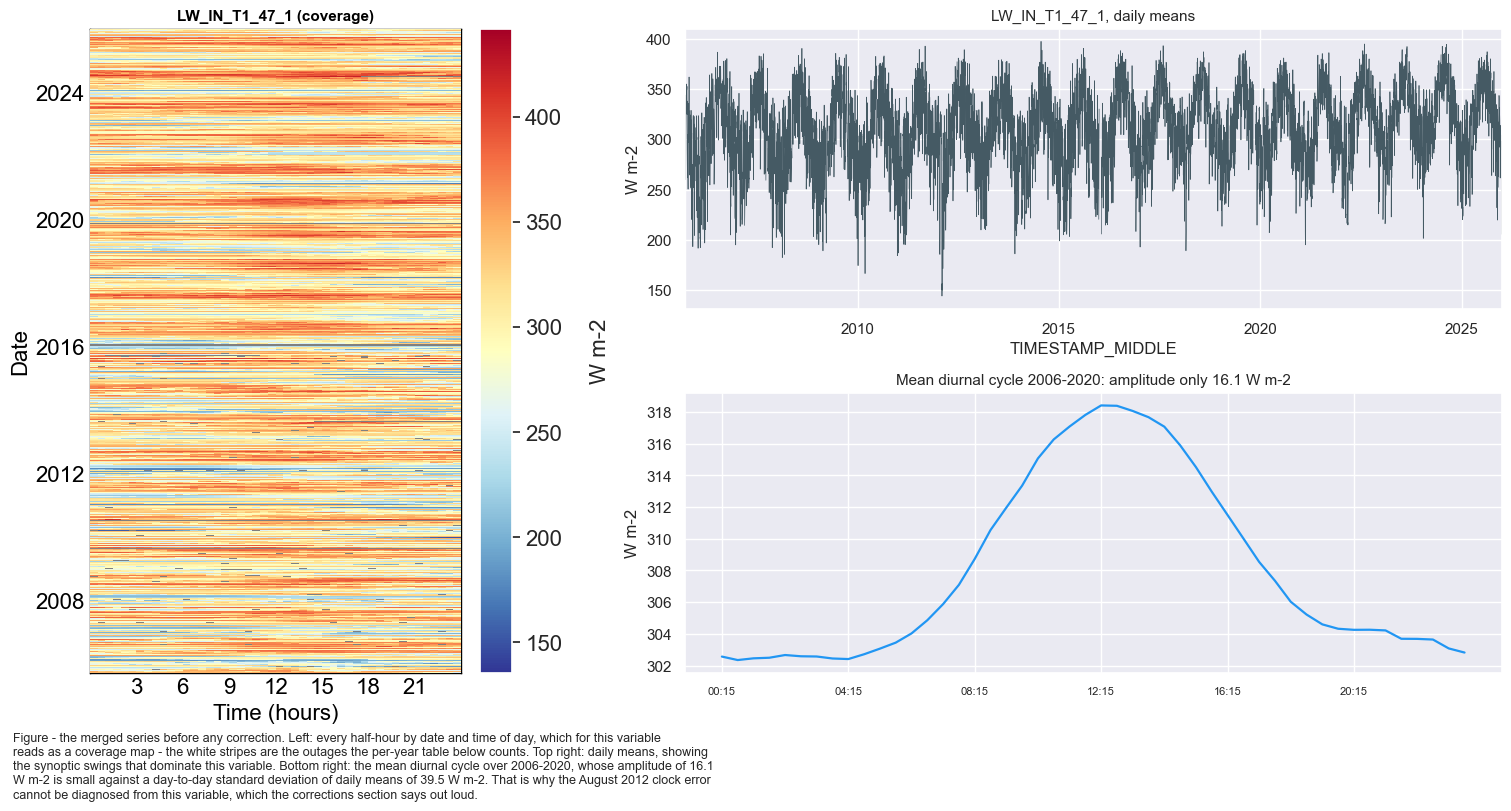

In [12]:
fig = plt.figure(figsize=(15, 8), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_di = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=lw_2005_2025[TARGET]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=f'{TARGET} (coverage)', title_fontsize=11))

lw_2005_2025[TARGET].resample('1D').mean().plot(ax=ax_ts, lw=0.5, color='#455A64')
ax_ts.set_ylabel('W m-2')
ax_ts.set_title(f'{TARGET}, daily means', fontsize=11)

_dc = lw_2005_2025.loc['2006':'2020', TARGET]
_dc = _dc.groupby(_dc.index.time).mean()
ax_di.plot(range(len(_dc)), _dc.values, color='#2196F3', lw=1.6)
ax_di.set_xticks(range(0, len(_dc), 8))
ax_di.set_xticklabels([str(t)[:5] for t in _dc.index[::8]], fontsize=8)
ax_di.set_ylabel('W m-2')
ax_di.set_title(f'Mean diurnal cycle 2006-2020: amplitude only '
                f'{_dc.max() - _dc.min():.1f} W m-2', fontsize=11)

_daily_sd = lw_2005_2025.loc['2006':'2020', TARGET].resample('1D').mean().std()
figcap(fig, f"the merged series before any correction. Left: every half-hour by date and time of "
            f"day, which for this variable reads as a coverage map - the white stripes are the "
            f"outages the per-year table below counts. Top right: daily means, showing the "
            f"synoptic swings that dominate this variable. Bottom right: the mean diurnal cycle "
            f"over 2006-2020, whose amplitude of {_dc.max() - _dc.min():.1f} W m-2 is small "
            f"against a day-to-day standard deviation of daily means of {_daily_sd:.1f} W m-2. "
            f"That is why the August 2012 clock error cannot be diagnosed from this variable, "
            f"which the corrections section says out loud.")

***

## ✴️ Corrections

### Timestamp shift in August 2012

**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects **every variable that logger recorded**.
`LW_IN_T1_47_1` sits on tower 1 at 47 m, on the same acquisition system as `SW_IN_T1_47_1`,
`TA_T1_47_1`, `PPFD_IN_T1_47_1` and `PA_T1_47_1`, so the same `+15.5 h` correction is applied.

::: {.callout-warning title="This correction is applied on provenance, and cannot be verified from LW_IN itself"}
The other notebooks each had a way to *check* the shift:

- `01` (`SW_IN`) against **solar geometry** — radiation must peak at solar noon, so a 15.5 h error
  is glaring.
- `02` (`TA`) and `05` (`PA`) against an **independent NABEL instrument** on a different
  acquisition system.

`LW_IN` has neither. Its diurnal cycle is some 16 W m-2 against synoptic swings several times
larger, so solar geometry gives almost no leverage, and there is no second pyrgeometer at the site.

The obvious internal check does not work either: the natural reference would be `TA_T1_47_1`, but
that sensor is **on the same logger**, so a clock error shifts longwave and temperature together and
leaves their relationship intact. An internal test cannot detect a shift that moves all of its
inputs equally.

So the justification here is **provenance, not measurement**: the fault is documented in the
fieldbook as a logger clock error, the logger is shared, and the shift has been independently
confirmed on that logger by three other variables — `SW_IN` against the sun, and `PA` against the
NABEL barometer (RMSE 0.324 -> 0.046 kPa on 11 August, see notebook `05`). Applying it to `LW_IN`
follows from the shift being a property of the *clock*, which is shared, rather than of any
instrument.

The plot below is shown for the record, not as evidence. It is not a validation.
:::

In [13]:
ISSUE_START = '2012-08-09 00:00'
ISSUE_END = '2012-08-17 00:00'
SHIFT_HOURS = 15.5

_df = lw_2005_2025.copy()
_before = _df[TARGET].copy()   # kept for the before/after plot

# Take the mis-stamped block and move it onto the correct time axis.
_series_shifted = _df.loc[ISSUE_START:ISSUE_END, TARGET].dropna()
_series_shifted.index = _series_shifted.index + pd.Timedelta(hours=SHIFT_HOURS)

# Clear everything between the start of the issue and the last shifted timestamp, then write the
# corrected values back. Same procedure as notebooks 01-03 and 05.
_df.loc[ISSUE_START:_series_shifted.index[-1], TARGET] = np.nan
_df.loc[_series_shifted.index, TARGET] = _series_shifted

print(f"shifted {len(_series_shifted):,} records by +{SHIFT_HOURS} h")
print(f"last shifted timestamp (corrected axis): {_series_shifted.index[-1]}")
print("\nApplied on provenance (shared logger). LW_IN cannot confirm or refute this on its own - "
      "see the note above.")

shifted 376 records by +15.5 h
last shifted timestamp (corrected axis): 2012-08-17 11:15:00

Applied on provenance (shared logger). LW_IN cannot confirm or refute this on its own - see the note above.


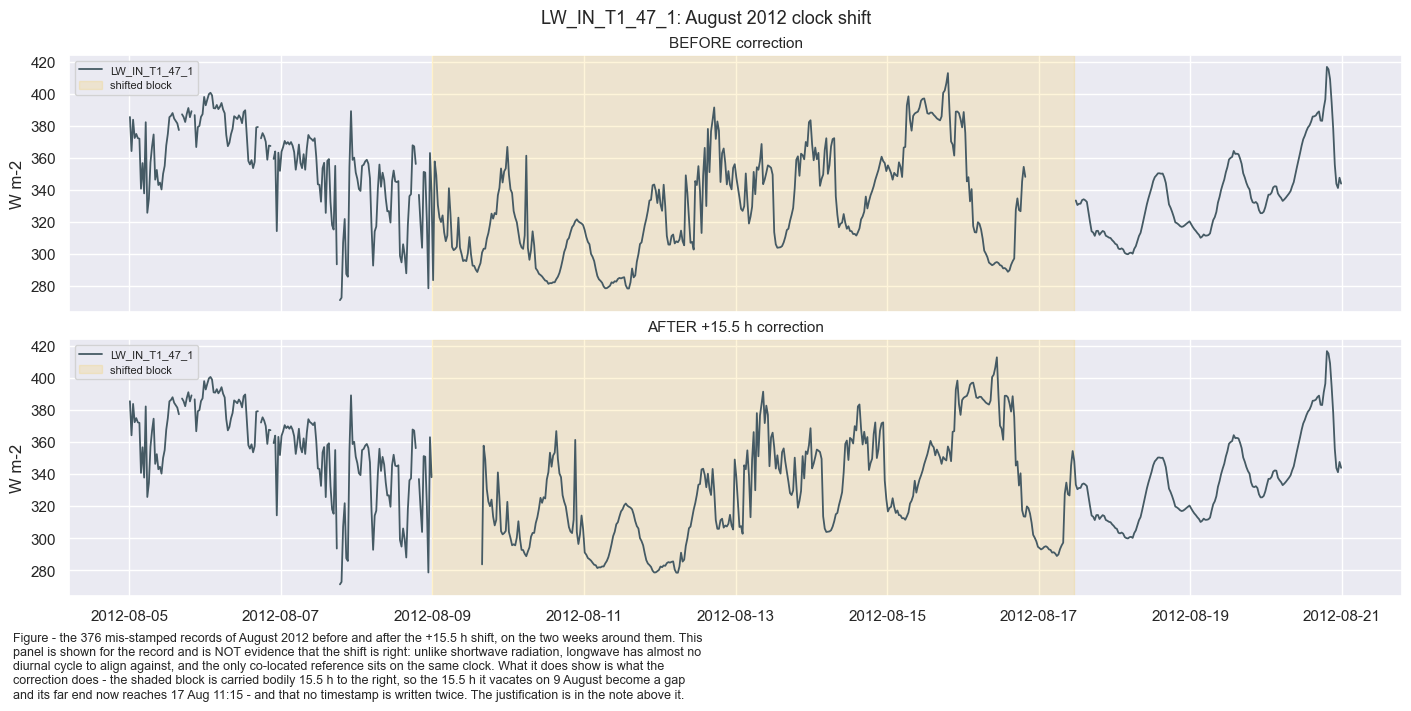

In [14]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained',
                        sharex=True, sharey=True)
fig.suptitle(f'{TARGET}: August 2012 clock shift', fontsize=13)
_win = slice('2012-08-05', '2012-08-20')

for _ax, _series, _title in [(axs[0], _before, 'BEFORE correction'),
                             (axs[1], _df[TARGET], f'AFTER +{SHIFT_HOURS} h correction')]:
    _ax.plot(_series.loc[_win].index, _series.loc[_win].values, color='#455A64', lw=1.3,
             label=TARGET)
    _ax.axvspan(pd.Timestamp('2012-08-09'), pd.Timestamp('2012-08-17 11:15'),
                color='#FFC107', alpha=.15, label='shifted block')
    _ax.set_title(_title, fontsize=11)
    _ax.set_ylabel('W m-2')
    _ax.legend(fontsize=8, loc='upper left')

figcap(fig, f"the {len(_series_shifted):,} mis-stamped records of August 2012 before and after the "
            f"+{SHIFT_HOURS} h shift, on the two weeks around them. This panel is shown for the "
            f"record and is NOT evidence that the shift is right: unlike shortwave radiation, "
            f"longwave has almost no diurnal cycle to align against, and the only co-located "
            f"reference sits on the same clock. What it does show is what the correction does - "
            f"the shaded block is carried bodily {SHIFT_HOURS} h to the right, so the "
            f"{SHIFT_HOURS} h it vacates on 9 August become a gap and its far end now reaches "
            f"{_series_shifted.index[-1]:%d %b %H:%M} - and that no timestamp is written twice. "
            f"The justification is in the note above it.")

In [15]:
lw_2005_2025 = _df.copy()

### Damaged periods in 2012

Notebooks `01`, `02` and `03` remove three windows in 2012, caused by a tower power supply failure
in late July / early August and by storm damage and stressed cables in late October / early
November, both documented in the fieldbook:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

**`LW_IN` shows no internal sign of either fault**, which is a genuine null result and is computed
below rather than asserted. The sensor reported a full 48 records a day throughout, never froze, and
stayed physically sensible the whole time.

**A null result is not an all-clear.** Three reasons it proves less than it appears to:

1. The emissivity check uses `TA_T1_47_1`, which is **on the same logger** and is itself degraded in
   exactly these windows (notebook `02` documents it). A ratio of two suspect quantities can look
   normal while both are wrong.
2. `LW_IN` varies from 135 to 442 W m-2 naturally, so a bias of tens of W m-2 hides inside ordinary
   weather. `PA` only exposed its fault because an independent barometer agreed to 0.04 kPa.
3. The fault in `PA` was a **level error**, not a dropout or a freeze — precisely the failure mode
   that this variable, without a reference, cannot see.

**Decision: the shared windows from `01`-`03` are removed.** With no evidence either way, the
conservative choice is to discard data that a documented, logger-wide fault could plausibly have
corrupted rather than keep it on the strength of a test known to be underpowered. `LW_IN` is a
47 m tower radiation sensor on the same system as `SW_IN`, which is unambiguously affected.

This is the **opposite** of the choice made for `PA` in notebook `05`, and deliberately so: there,
an independent barometer positively demonstrated that 28-29 October were sound, which justified
keeping them. Narrowing a window requires positive evidence of cleanliness, and absence of evidence
is not that. The windows here are therefore identical to `01`-`03`, including the 17-18 August
transitional tail.

In [16]:
# Identical to notebooks 01-03. Windows are on the CORRECTED time axis (after the +15.5 h shift).
# Kept deliberately wide: LW_IN has no independent reference, so there is no evidence on which to
# narrow them (unlike PA in notebook 05). See the discussion above.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

# The null result, computed rather than quoted, so a future re-run cannot silently disagree with
# the text above.
_emis_2012 = emissivity(lw_2005_2025[TARGET])
_rows = []
for _lo, _hi, _lab in [('2012-06-01', '2012-07-25', 'baseline 1 Jun - 25 Jul'),
                       ('2012-07-29', '2012-08-10', 'window 1 (power supply)'),
                       ('2012-10-28', '2012-11-10', 'window 3 (storm damage)')]:
    _e = _emis_2012.loc[_lo:_hi].dropna()
    _v = lw_2005_2025.loc[_lo:_hi, TARGET].dropna()
    _rows.append({'period': _lab, 'n': len(_e),
                  'emissivity median': round(float(_e.median()), 3),
                  'emissivity min': round(float(_e.min()), 3),
                  'emissivity max': round(float(_e.max()), 3),
                  'outside 0.60-1.06 (%)': round(100 * float(((_e < 0.60) | (_e > 1.06)).mean()), 2),
                  'repeated values': int(_v.diff().eq(0).sum())})
tabcap("what the two suspect 2012 windows look like from inside this variable, against the seven "
       "clean weeks that precede them. By every measure available without a reference the windows "
       "are indistinguishable from the baseline, which is the null result the text above discusses")
display(pd.DataFrame(_rows).set_index('period'))

_before_n = int(lw_2005_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    lw_2005_2025.loc[_start:_end, TARGET] = np.nan
_removed = _before_n - int(lw_2005_2025[TARGET].notna().sum())
print(f"Removed {_removed:,} records from {TARGET} on provenance grounds "
      f"(left as gaps, nothing is filled).")

Table - what the two suspect 2012 windows look like from inside this variable, against the seven
clean weeks that precede them. By every measure available without a reference the windows are
indistinguishable from the baseline, which is the null result the text above discusses



,n,emissivity median,emissivity min,emissivity max,outside 0.60-1.06 (%),repeated values
period,,,,,,
baseline 1 Jun - 25 Jul,2619,0.861,0.667,1.031,0.0,0
window 1 (power supply),17,0.747,0.728,0.877,0.0,0
window 3 (storm damage),48,0.981,0.858,1.002,0.0,0


Removed 1,202 records from LW_IN_T1_47_1 on provenance grounds (left as gaps, nothing is filled).


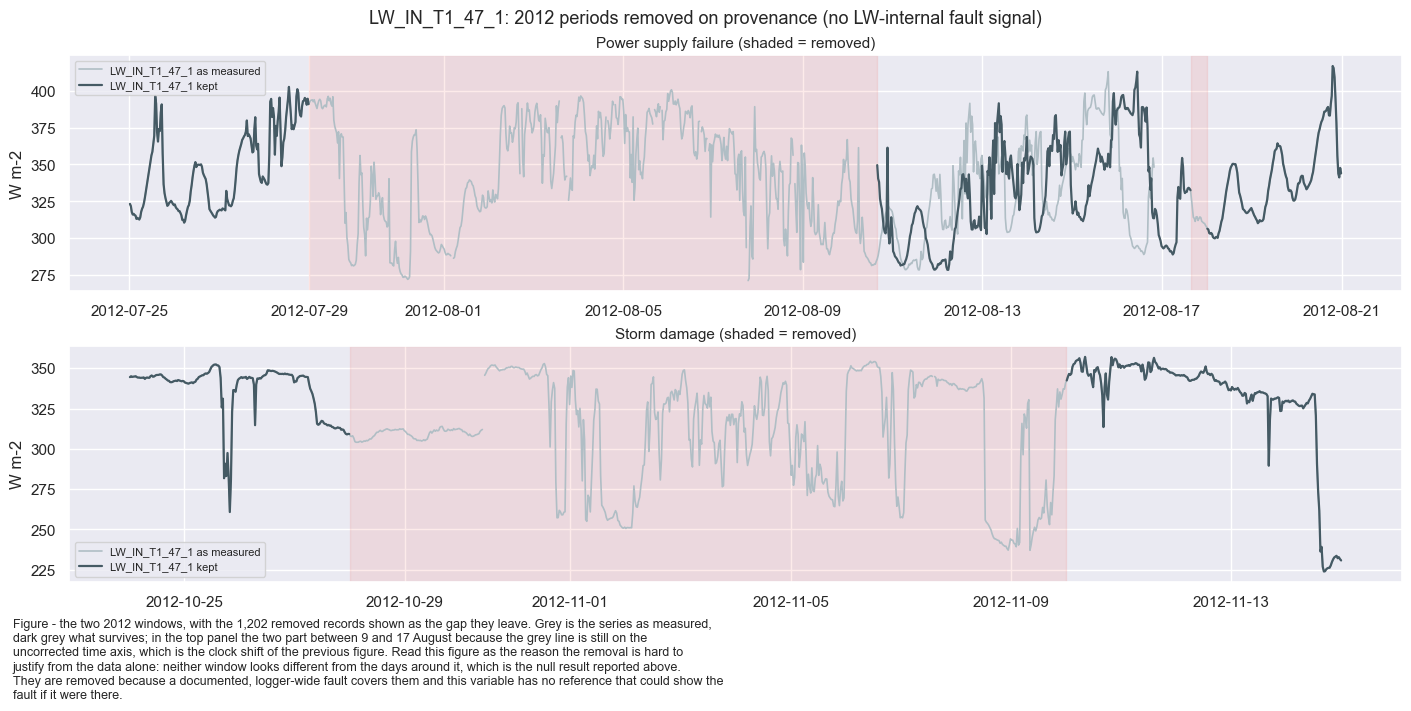

In [17]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle(f'{TARGET}: 2012 periods removed on provenance (no LW-internal fault signal)',
             fontsize=13)

for _ax, (_lo, _hi, _label) in zip(axs, [('2012-07-25', '2012-08-20', 'Power supply failure'),
                                         ('2012-10-24', '2012-11-14', 'Storm damage')]):
    _w = slice(_lo, _hi)
    _ax.plot(_before.loc[_w].index, _before.loc[_w].values, color='#B0BEC5', lw=1.2,
             label=f'{TARGET} as measured')
    _ax.plot(lw_2005_2025[TARGET].loc[_w].index, lw_2005_2025[TARGET].loc[_w].values,
             color='#455A64', lw=1.6, label=f'{TARGET} kept')
    for _s, _e in BAD_WINDOWS_2012:
        if pd.Timestamp(_s) <= pd.Timestamp(_hi) and pd.Timestamp(_e) >= pd.Timestamp(_lo):
            _ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color='#F44336', alpha=.10)
    _ax.set_title(f'{_label} (shaded = removed)', fontsize=11)
    _ax.set_ylabel('W m-2')
    _ax.legend(fontsize=8, loc='best')

figcap(fig, f"the two 2012 windows, with the {_removed:,} removed records shown as the gap they "
            f"leave. Grey is the series as measured, dark grey what survives; in the top panel the "
            f"two part between 9 and 17 August because the grey line is still on the uncorrected "
            f"time axis, which is the clock shift of the previous figure. Read this figure as the "
            f"reason the removal is hard to justify from the data alone: neither window looks "
            f"different from the days around it, which is the null result reported above. They are "
            f"removed because a documented, logger-wide fault covers them and this variable has no "
            f"reference that could show the fault if it were there.")

::: {.callout-note title="No nighttime zero-offset correction here"}
Notebooks `01` and `03` remove a nighttime zero-offset from `SW_IN` and `PPFD_IN`, because those
quantities have a known true value at night — zero — so any nonzero nighttime reading is measurable
sensor offset.

`LW_IN` is a radiation quantity too, but that correction would be **physically wrong** here.
Downwelling longwave is thermal emission from the atmosphere and continues all night; at this site
it is typically 250-350 W m-2 at 03:00. Forcing nighttime `LW_IN` to zero would destroy roughly half
the record.

As in `05`, the trap from notebook `03` — a correction writing into gaps and thereby relabelling
fills as measurements — **cannot occur here**: no correction writes a value into a missing record.
The clock shift moves existing records, and the 2012 windows only ever set values to `NaN`.
:::

***

## 🔎 Which sensor this is, and what the hardware changes did to it

On 21 January 2016 the tower's data logger was replaced, and notebook `02` established that
`TA_T1_47_1` steps by about 1.3 °C across that changeover. The same acquisition system carries
`LW_IN_T1_47_1`, so the question of whether this series moved as well has to be answered rather
than assumed — and in December 2021 the radiometer itself was replaced, which is the other date a
user of this variable needs an answer about.

Both questions have to be answered **without any reference instrument**. What takes its place is
the physics of the measurement, and one specific property of it: a pyrgeometer converts a voltage
proportional to the **net** exchange between the sky and its own body, so an error in that
conversion is **proportional to `LW_net`**. It is therefore largest under a clear sky and vanishes
under low overcast, where `LW_net` goes to zero. That gives two statistics with opposite
sensitivities, and neither of them is a statement about how cloudy a year was:

- the **clear-sky envelope**, the 2nd percentile of nighttime `LW_net`, where a conversion error is
  at its largest;
- the **overcast ceiling**, the 95th percentile of nighttime apparent emissivity, which is pinned
  near 1.00 by the physics of a low cloud base radiating at nearly air temperature, and where a
  conversion error is at its smallest.

Nighttime only, for both: an unventilated pyrgeometer heats in sunlight, so daytime records carry a
solar error that has nothing to do with the questions being asked here. This is the same
split-night-from-day rule notebook `02` applies to `TA`.

Running these over the whole record rather than at the two candidate dates turns up a change that
is larger than either of them, and that nobody had looked for:

1. **the instrument is one Kipp & Zonen CNR1, serial 020484**, until December 2021, and both of its
   radiometer channels were converted with the **same** constant — which is a statement about the
   absolute accuracy of this series;
2. **the pyrgeometer's calibration factor was corrected on 7 June 2016**, from 10.03 to
   12.83 µV/W/m², and the exported series steps there. This is the one real inhomogeneity in this
   product;
3. **the January 2016 acquisition change did nothing** — the change is five months later, and the
   logger program installed at the changeover carries the old constant;
4. **the December 2021 boundary also moves the record**, by about half as much, and this notebook
   **cannot say why**. Two candidate causes fall on the same date and neither can be tested without
   a reference.

### Helpers for this section

The logger programs and the maintenance record are read in the notebook rather than quoted, so
that a re-run re-derives the argument instead of inheriting a stale copy of it. Both are signed by
the people who did the work and this notebook renders to a public page, so every string taken out
of either passes through the same redaction used in notebooks `01`, `02`, `03` and `08`.

In [18]:
# --- Fieldbook and logger-program redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebooks 01, 02, 03 and 08; the map lives beside the
# export, OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the
    second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as 'the program does not measure this', and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


def calibration_constants(excerpt: str) -> dict:
    """The multiplier and offset of one measurement instruction, parsed from its own text.

    The two program languages write the same two numbers differently - the CR10X lists them as
    numbered parameters, the CR1000 as positional arguments - so each is matched on its own shape.
    Raises if either number cannot be found, because a silently empty dict would make the
    comparison below pass by having nothing to disagree about. Pass an excerpt holding exactly one
    instruction: with two, the first one wins and the answer is about the wrong channel.
    """
    if 'Mult' in excerpt:                                    # CR10X parameter listing
        mult = re.search(r'^\s*\d+:\s*([\d.]+)\s+Mult', excerpt, re.M)
        offset = re.search(r'^\s*\d+:\s*([\d.]+)\s+Offset', excerpt, re.M)
    else:                                                    # CR1000 VoltDiff(...) call
        call = re.search(r'VoltDiff\s*\(([^)]*)\)', excerpt)
        args = [a.strip() for a in call.group(1).split(',')] if call else []
        mult = re.match(r'([\d.]+)$', args[-2]) if len(args) >= 2 else None
        offset = re.match(r'([\d.]+)$', args[-1]) if len(args) >= 2 else None
    if not (mult and offset):
        raise ValueError("could not parse a multiplier and an offset from the instruction - the "
                         "program language or the layout has changed")
    return {'multiplier': float(mult.group(1)), 'offset': float(offset.group(1))}

In [19]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so every
# failure path is exercised before anything is read.
try:
    program_excerpt(PROGRAM_AFTER, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

# And the constant parser must refuse an instruction it cannot read, rather than return an empty
# comparison that would agree with anything.
try:
    calibration_constants("19:  Volt (Diff) (P2) ;Messung von Lin\n 1: 1        Reps")
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an instruction with no constants: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted an instruction carrying no constants.")

OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, the unknown-name net fired on a name that is not in the map
OK, calibration_constants raised on an instruction with no constants: could not parse a multiplier and an offset from the instruction - the program language or the layout has changed


### 1️⃣ One instrument, and one constant for both of its radiometer channels

Every surviving logger program is read here and the two constants of the **longwave** instruction
parsed out of its own text, so the comparison is made on every run rather than on the reading
someone once made of it. The shortwave instruction is parsed alongside, because the relation
between the two is the point of this step.

In [20]:
# Every logger program on disk that measures this channel, read rather than quoted. The CR10X
# programs are listed oldest first; the CR1000 program is the one installed at the 2016 changeover.
# Two excerpts are taken from each file: a wide one to display, which shows both radiometer
# channels together, and a single-instruction one for the parser, because calibration_constants()
# takes the first instruction it finds and a wide excerpt would answer about the wrong channel.
LW_CONSTANTS, SW_CONSTANTS = {}, {}
_excerpts = []

print("=" * 78)
print("BEFORE 2016: the CR10X programs")
print("=" * 78)
for _p in PROGRAMS_BEFORE:
    _wide = program_excerpt(_p, r'Messung von Lin', before=13, after=6)
    _excerpts.append(_wide)
    LW_CONSTANTS[Path(_p).name] = calibration_constants(
        program_excerpt(_p, r'Messung von Lin', before=0, after=6))
    SW_CONSTANTS[Path(_p).name] = calibration_constants(
        program_excerpt(_p, r'Messung von Kin', before=0, after=6))
    print(f"\n--- {Path(_p).name}")
    print(_wide)

print("\n" + "=" * 78)
print(f"AFTER 2016:  {Path(PROGRAM_AFTER).name}")
print("=" * 78)
_cr1000_wide = program_excerpt(PROGRAM_AFTER, r'VoltDiff\(LW_IN_T1_47_1', before=7, after=0)
_excerpts.append(_cr1000_wide)
LW_CONSTANTS[Path(PROGRAM_AFTER).name] = calibration_constants(
    program_excerpt(PROGRAM_AFTER, r'VoltDiff\(LW_IN_T1_47_1', before=0, after=0))
SW_CONSTANTS[Path(PROGRAM_AFTER).name] = calibration_constants(
    program_excerpt(PROGRAM_AFTER, r'VoltDiff\(SW_IN_T1_47_1', before=0, after=0))
print(_cr1000_wide)

# These files are signed by their authors, so they get the same two nets as the fieldbook:
# redaction inside program_excerpt, and the unknown-name audit here.
audit_unmapped_names(_excerpts, 'logger programs')

tabcap("the conversion each surviving logger program applied to the two radiometer channels. The "
       "two channels of one instrument have different sensitivities, but every program on disk "
       "converts them with the same constant")
_const = pd.DataFrame({'LW_IN multiplier': {k: v['multiplier'] for k, v in LW_CONSTANTS.items()},
                       'LW_IN offset': {k: v['offset'] for k, v in LW_CONSTANTS.items()},
                       'SW_IN multiplier': {k: v['multiplier'] for k, v in SW_CONSTANTS.items()},
                       'implied sensitivity (uV/W/m2)':
                           {k: round(1000 / v['multiplier'], 3) for k, v in LW_CONSTANTS.items()}})
_const.index.name = 'logger program'
display(_const)

_lw_mults = {v['multiplier'] for v in LW_CONSTANTS.values()}
_lw_offs = {v['offset'] for v in LW_CONSTANTS.values()}
print(f"\ndistinct LW_IN multipliers across all {len(LW_CONSTANTS)} programs: {sorted(_lw_mults)}")
print(f"distinct LW_IN offsets:    {sorted(_lw_offs)}")
assert len(_lw_mults) == 1 and _lw_offs == {0.0}, (
    "the surviving programs no longer all apply one conversion to the longwave channel - the "
    "argument that the January 2016 changeover cannot have moved this series has to be re-derived")

# The statement this step exists to make: the pyrgeometer was converted with the PYRANOMETER's
# calibration factor. Both channels carry the same multiplier in every program on disk.
assert all(LW_CONSTANTS[_k]['multiplier'] == SW_CONSTANTS[_k]['multiplier'] for _k in LW_CONSTANTS), (
    "the two radiometer channels no longer share a multiplier in every program, so the absolute-"
    "accuracy statement below no longer describes these files")
SENSITIVITY_PROGRAM = 1000 / max(_lw_mults)
print(f"implied sensitivity on both channels: {SENSITIVITY_PROGRAM:.2f} uV/W/m2, which is the "
      f"CNR1 calibration factor the programs' own comments give for the instrument")

BEFORE 2016: the CR10X programs

--- LAEGEREN.20050818.CSI
;-----------------------------------------------------------------------
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
;-----------------------------------------------------------------------


18:  Volt (Diff) (P2) ;Messung von Kin
 1: 1        Reps
 2: 33       25 mV 50 Hz Rejection Range
 3: 3        DIFF Channel
 4: 23       Loc [ Kin       ]
 5: 99.7009  Mult
 6: 0.0      Offset

19:  Volt (Diff) (P2) ;Messung von Lin
 1: 1        Reps
 2: 32       7.5 mV 50 Hz Rejection Range
 3: 4        DIFF Channel
 4: 25       Loc [ Lin       ]
 5: 99.7009  Mult
 6: 0.0      Offset

--- LAEGEREN.20050914.CSI
;-----------------------------------------------------------------------
; Net Radiometer CNR1 from NABEL-Station,sn: 020484, factor=10.03uV/W/m2
;-----------------------------------------------------------------------


18:  Volt (Diff) (P2) ;Messung von Kin
 1: 1        Reps
 2: 33       25 mV 50 Hz Re

,LW_IN multiplier,LW_IN offset,SW_IN multiplier,implied sensitivity (uV/W/m2)
logger program,,,,
LAEGEREN.20050818.CSI,99.7009,0.0,99.7009,10.03
LAEGEREN.20050914.CSI,99.7009,0.0,99.7009,10.03
LAEGEREN.20060524.csi,99.7009,0.0,99.7009,10.03
CH-LAE_iDL_T1_47_1.CR1,99.7009,0.0,99.7009,10.03



distinct LW_IN multipliers across all 4 programs: [99.7009]
distinct LW_IN offsets:    [0.0]
implied sensitivity on both channels: 10.03 uV/W/m2, which is the CNR1 calibration factor the programs' own comments give for the instrument


Both acquisition systems measure **the same physical instrument**, a Kipp & Zonen CNR1 with serial
number 020484, and both convert **both of its radiometer channels with one constant**, the 10.03
µV/W/m² named in the programs' comments. That constant belongs to the pyranometer.

That matters for the absolute accuracy of this series, and it is not a small effect. A CNR1's four
sensors are calibrated individually and their sensitivities differ: when the successor instrument
arrived, the site's own record listed 13.89 µV/W/m² for its shortwave channel against 10.85 for its
longwave one, a difference of 28 %. Using one channel's figure for the other therefore scales the
pyrgeometer's net signal by whatever the ratio between them happens to be — and because the error
is proportional to `LW_net`, it is largest under a clear sky and vanishes under overcast. It is not
a constant offset that a reader could subtract.

This is not a hypothesis about the past. The next step shows that somebody found this and corrected
it, mid-record.

::: {.callout-note title="What the programs cover, and what they do not"}
Three CR10X programs carry this measurement, spanning August 2005 to May 2006, and the CR1000
program dates from January 2016. **No tower program between May 2006 and January 2016 survives on
disk, and none after January 2016 at all.** The programs establish two endpoints; everything
between and after them has to come from the data and from the maintenance record — which is exactly
where the change this section reports is found, because the program that made it is one of the ones
that did not survive.
:::

### 2️⃣ What the maintenance record holds for this radiometer

Evidence first, fieldbook second: the statistics below were scanned blind over the whole record
before the fieldbook was asked what happened. The record is read and filtered here rather than
quoted, and filtered on the **device columns as well as the free text**, because the entries that
explain a radiometer are routinely filed under the logger.

In [21]:
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")

_dev = fb[['Device Name', 'Device Model']].astype(str).agg(' '.join, axis=1)
_RADIOMETER = r'CNR1|CNR4|net ?radiom|NetRad|Kipp|pyrgeo|LW_IN|Eichfaktor'
_by_device = _dev.str.contains(_RADIOMETER, case=False, regex=True, na=False)
_by_text = fb['text'].str.contains(_RADIOMETER, case=False, regex=True, na=False)
# 1 January 2016 and the other backdated rows are the GIN inventory import, not events.
hits = fb[(_by_device | _by_text) & (fb['Date'] != '2016-01-01')].sort_values('Date')
assert len(hits) > 0, "no radiometer entries at all - is this the right export?"
print(f"entries naming the radiometer: {len(hits)} "
      f"({int(_by_device.sum())} by device column, {int(_by_text.sum())} by free text)")


def fragment(text, pattern=_RADIOMETER, width=70) -> str:
    """The part of one entry that names the radiometer, rather than its first hundred characters.

    Several of these entries are whole-day visit reports in which the instrument is named once,
    halfway through; truncating from the start shows the drive to the site instead.
    """
    _m = re.search(pattern, str(text), re.I)
    if not _m:
        return str(text)[:2 * width]
    _lo, _hi = max(0, _m.start() - width), min(len(str(text)), _m.end() + width)
    return ('...' if _lo else '') + str(text)[_lo:_hi] + ('...' if _hi < len(str(text)) else '')


tabcap("every fieldbook entry naming the tower radiometer over the whole record, shown around the "
       "words that name it. Rows whose device columns read 'na' were found by the free text alone; "
       "the two entries that matter most for this product are among them, which is why the device "
       "filter alone is not enough")
_show = hits[['Date', 'Device Model', 'Operation Tag', 'text']].copy()
_show['Date'] = _show['Date'].dt.date
_show['text'] = _show['text'].apply(fragment)
with pd.option_context('display.max_colwidth', 150, 'display.max_rows', 60):
    display(_show.set_index('Date'))

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17
entries naming the radiometer: 29 (9 by device column, 25 by free text)
Table - every fieldbook entry naming the tower radiometer over the whole record, shown around the
words that name it. Rows whose device columns read 'na' were found by the free text alone; the two
entries that matter most for this product are among them, which is why the device filter alone is
not enough



,Device Model,Operation Tag,text
Date,,,
2011-06-03,na,na,...tation was necessary 07.10.2008 (person 07) Meteo Replaced relais for CNR1 (Meteo-logger CR10X on tower) 01.10.2008 (person 22) QCLAS-system mo...
2016-01-08,na,na,...struments A100LK cup anemometer wwith SN 16697 installed a new direct Kipp&Zonen par ( SN:) sensor and replaced the reflective par ( SN:) on th...
2016-05-26,na,na,...ule (after the IRGA cell) Radiation boom in from 9:30 to 9:50 checked CNR1 NetRadiometer (NABEL) connection to our tower logger. all correct. r...
2016-05-27,na,na,...am to the logger again and tried some minor program changes to avoid skipped system scans –> not yet suceeded
2016-05-30,na,na,.... Data is saved as data table. Checked function of the logger. Still skipped system scans and 2 skipped scans. Probalby during referencing. The...
2016-06-07,na,na,"...riables: WD_VANE_T1_47_1_AVG, WD_VANE_T1_47_1_Std New variable Public LW_IN_COR_T1_47_1 and LW_OUT_COR_T1_47_1 (not in variabel list) values wi..."
2016-06-17,na,na,...his scritp is running in sequential mode again. Thias leads to minor skipped system scans but should solve most of the other timing issues. The...
2016-12-12,na,na,"...ter of the li7200, reinstalled filter and inlet tube cleaned BF3, and Kipp&Zonen PAR lite. 15:00 set T1B3 boom back cleaned the profile windson..."
2018-05-29,CNR1,na,Added device to site.


In [22]:
# The one entry this section turns on, printed in full. It is found by searching for the two
# calibration factors rather than by its date, so a re-export that moved the date still finds it.
_cal_entries = fb[fb['text'].str.contains(r'calibration factor changed', case=False, na=False)]
assert len(_cal_entries) >= 1, (
    "the fieldbook no longer records a change of the radiometer calibration factor - the whole of "
    "step 3 rests on this entry and must be re-derived")
_cal = _cal_entries.sort_values('Date').iloc[0]
CAL_ENTRY_DATE = _cal['Date']
print(f"--- {CAL_ENTRY_DATE.date()}")
print(textwrap.fill(_cal['text'], 110))

# The two numbers are read out of the entry rather than typed here, so the constants used below
# cannot drift away from the record that justifies them.
_m = re.search(r'calibration factor changed from ([\d.]+) to ([\d.]+)', _cal['text'], re.I)
assert _m, "the calibration-factor sentence no longer has the shape this cell parses"
SENSITIVITY_OLD, SENSITIVITY_NEW = float(_m.group(1)), float(_m.group(2))
CAL_RATIO_DOCUMENTED = SENSITIVITY_OLD / SENSITIVITY_NEW
print(f"\npyrgeometer calibration factor: {SENSITIVITY_OLD} -> {SENSITIVITY_NEW} uV/W/m2")
print(f"the net longwave signal of the earlier era is therefore too large by "
      f"{100 * (1 / CAL_RATIO_DOCUMENTED - 1):.1f} %, i.e. it has to be multiplied by "
      f"{CAL_RATIO_DOCUMENTED:.4f} to be on the later era's calibration")
assert abs(SENSITIVITY_OLD - SENSITIVITY_PROGRAM) < 0.01, (
    "the factor the entry replaces is no longer the one the logger programs apply, so the entry "
    "and the programs are no longer describing the same measurement")
assert pd.Timestamp(CAL_ENTRY_DATE).year == 2016, (
    "the calibration-factor entry has moved out of 2016 - re-derive the era boundaries below")

--- 2016-06-07


07.06.2016 (person 01) downloaded manually the logger data from logger CH-LAE_iDL_T1_47_1 to the embedded and
saved the loggernet tables to the data upload folder uploaded new loggerprogram CH-LAE_CR1000_T1_47_1_20160606
to the logger. The program corrects following bugs: New variable windvector replaces 'Average
(1,WD_VANE_T1_47_1,IEEE4,False)' which clearly leads to incorrect values. New variables:
WS_CUP_SCALAR_T1_47_1_WVc(1), WS_CUP_SCALAR_T1_47_1_WVc(2), WS_CUP_SCALAR_T1_47_1_WVc(3),
WS_CUP_SCALAR_T1_47_1_WVc(4). Removed variables: WD_VANE_T1_47_1_AVG, WD_VANE_T1_47_1_Std New variable Public
LW_IN_COR_T1_47_1 and LW_OUT_COR_T1_47_1 (not in variabel list) values with boltzmann correction function. New
variables in table: , LW_IN_COR_T1_47_1_Avg, LW_OUT_COR_T1_47_1_Avg, LW_IN_COR_T1_47_1_Std,
LW_OUT_COR_T1_47_1_Std. Keeping LW_IN_T1_47_1 and LW_OUT_T1_47_1 besides this variable actually should be
named LW_IN_RAW_T1_47_1 and LW_IN_RAW_T1_47_1 according to variable naming of the gl g

The entry does two things at once, on **7 June 2016**. It introduces `LW_IN_COR_T1_47_1`, the
variable the `diive` data version reads from 2022 onwards, and it explains what `COR` means: the
Stefan-Boltzmann term. And it records that the pyrgeometer's calibration factor was corrected from
the pyranometer's 10.03 µV/W/m² to the instrument's own 12.83, on information from the institution
that owns the radiometer.

The second of those is a **change to the measurement**, not to a variable name. Everything recorded
before it converts the pyrgeometer's voltage with a constant 28 % too small, and therefore reports a
net longwave signal 28 % too large in magnitude. The next step measures that in the data.

### 3️⃣ The June 2016 calibration change, measured in the data

The two statistics defined at the top of this section are computed here, per month and per year, and
scanned over the whole record. A calibration error acts on `LW_net`, so it moves the clear-sky
envelope and not the overcast ceiling, and it moves the envelope by the **same factor at every
percentile of it** — which is what separates it from a change in the weather.

In [23]:
# The two statistics, with their guards. Both are computed on nighttime records where TA was
# measured, and both raise rather than returning a thin result: a percentile built from a handful
# of half-hours reads exactly like one built from a thousand.
LW_FINAL = lw_2005_2025[TARGET]
LWNET_NIGHT = net_longwave(LW_FINAL).where(NIGHT)
EMIS_NIGHT = emissivity(LW_FINAL).where(NIGHT)
CLEAR_Q = 0.02          # the clear-sky envelope
OVERCAST_Q = 0.95       # the overcast ceiling
MIN_PER_MONTH = 200


def monthly_q(series: pd.Series, q: float, minrec: int = MIN_PER_MONTH) -> pd.Series:
    """Monthly quantile of `series`, months with fewer than `minrec` records dropped."""
    s = series.dropna()
    v, n = s.resample('MS').quantile(q), s.resample('MS').count()
    out = v[n >= minrec]
    if out.empty:
        raise ValueError(f"no month reaches {minrec} records - the statistic has no support")
    return out


def yearly_q(series: pd.Series, q: float, minrec: int = MIN_PER_MONTH,
             minmonths: int = 10) -> pd.Series:
    """Yearly quantile, taken per calendar month and then averaged over months.

    Month-matched on purpose: this variable has a strong seasonal cycle in both statistics, so a
    year short of a winter must not be compared against one that is not.
    """
    s = series.dropna()
    v = s.groupby([s.index.year, s.index.month]).quantile(q)
    v.index.names = ['year', 'month']
    n = s.groupby([s.index.year, s.index.month]).count()
    v = v[n >= minrec]
    keep = v.groupby(level=0).count()
    out = v.groupby(level=0).mean()
    out.index.name = 'YEAR'
    out = out[keep >= minmonths]
    if out.empty:
        raise ValueError(f"no year reaches {minmonths} months of at least {minrec} records")
    return out


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Percentage change of a yearly statistic across `year`, over `span` years either side.

    The candidate year itself is excluded from both sides: a change inside a year belongs to
    neither era. Returns nan when either side is thin, so a year at the edge of the record cannot
    win a scan by having almost no data behind it.
    """
    pre = series.reindex(range(year - span, year)).dropna()
    post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(pre) < 2 or len(post) < 2:
        return float('nan')
    return 100 * (post.mean() / pre.mean() - 1)


def matched_ratio(monthly: pd.Series, months, years_before, years_after) -> dict:
    """The clear-sky envelope over the same calendar months, before and after a date.

    Month-matched and close in time, which is what makes it a test of a date rather than of a
    decade: the same calendar months are compared, so the seasonal cycle cancels, and the two
    windows are adjacent, so a slow trend has little room to act. A candidate date inside a year
    is tested by splitting that year - the months before it against the same months of earlier
    years, and the months after it against the same months of earlier years.
    """
    a = monthly[monthly.index.month.isin(months) & monthly.index.year.isin(years_before)]
    b = monthly[monthly.index.month.isin(months) & monthly.index.year.isin(years_after)]
    if len(a) < len(months) or len(b) < max(1, int(0.8 * len(months))):
        raise ValueError(f"months {list(months)}: {len(a)} before and {len(b)} after reach the "
                         f"record threshold, too few to compare")
    return {'months compared': f'{len(a)} vs {len(b)}',
            'before (W m-2)': round(float(a.median()), 1),
            'after (W m-2)': round(float(b.median()), 1),
            'ratio': round(float(b.median() / a.median()), 4)}


def placebo_ratios(monthly: pd.Series, months, boundaries, span: int = 3) -> pd.Series:
    """The same statistic at every year of the record, on windows holding no known boundary.

    This is what the boundary values are read against. A year whose window straddles one of
    `boundaries` is dropped, because it would be reporting the very thing being tested.
    """
    out = {}
    for _y in range(int(monthly.index.year.min()) + span, int(monthly.index.year.max()) + 1):
        if any(_y - span <= pd.Timestamp(_b).year <= _y for _b in boundaries):
            continue
        try:
            out[_y] = matched_ratio(monthly, months, range(_y - span, _y), [_y])['ratio']
        except ValueError:
            continue
    if len(out) < 5:
        raise ValueError(f"only {len(out)} quiet years available - the reference distribution "
                         f"would be built on too little to mean anything")
    return pd.Series(out).sort_index()


ENVELOPE_M = monthly_q(LWNET_NIGHT, CLEAR_Q)
ENVELOPE_Y = yearly_q(LWNET_NIGHT, CLEAR_Q)
CEILING_Y = yearly_q(EMIS_NIGHT, OVERCAST_Q)
print(f"nighttime records with a measured TA: {int(LWNET_NIGHT.notna().sum()):,}")
print(f"months in the envelope series: {len(ENVELOPE_M)}   years: {len(ENVELOPE_Y)}")

nighttime records with a measured TA: 167,980
months in the envelope series: 244   years: 20


In [24]:
# The guards guard, again. Each helper would otherwise return a plausible number from almost no
# data, and each has its own way of doing so.
for _fn, _kw, _why in [(monthly_q, dict(minrec=10 ** 7), 'no month reaches the record threshold'),
                       (yearly_q, dict(minrec=10 ** 7), 'no year reaches the record threshold'),
                       (yearly_q, dict(minmonths=13), 'no year has thirteen calendar months')]:
    try:
        _fn(LWNET_NIGHT, CLEAR_Q, **_kw)
    except ValueError as _exc:
        print(f"OK, {_fn.__name__} raised on '{_why}': {_exc}")
    else:
        raise AssertionError(f"(!) {_fn.__name__} accepted a threshold no data can meet ({_why}).")

assert np.isnan(step_at(ENVELOPE_Y, 1990)), "(!) step_at returned a number for a year off the record"
assert np.isnan(step_at(ENVELOPE_Y, int(ENVELOPE_Y.index.max()))), \
    "(!) step_at returned a number for the last year, which has no years after it"
print("OK, step_at returns nan where one side of the comparison does not exist")

try:
    matched_ratio(ENVELOPE_M, [7, 8, 9], [1990, 1991, 1992], [2016])
except ValueError as _exc:
    print(f"OK, matched_ratio raised on years the record does not cover: {_exc}")
else:
    raise AssertionError("(!) matched_ratio accepted a window with no data before it.")

try:
    placebo_ratios(ENVELOPE_M, [7], [f'{_y}-01-01' for _y in range(2006, 2026)])
except ValueError as _exc:
    print(f"OK, placebo_ratios raised when every year was declared a boundary: {_exc}")
else:
    raise AssertionError("(!) placebo_ratios built a reference distribution out of nothing.")

OK, monthly_q raised on 'no month reaches the record threshold': no month reaches 10000000 records - the statistic has no support
OK, yearly_q raised on 'no year reaches the record threshold': no year reaches 10 months of at least 10000000 records


OK, yearly_q raised on 'no year has thirteen calendar months': no year reaches 13 months of at least 200 records
OK, step_at returns nan where one side of the comparison does not exist
OK, matched_ratio raised on years the record does not cover: months [7, 8, 9]: 0 before and 3 after reach the record threshold, too few to compare
OK, placebo_ratios raised when every year was declared a boundary: only 0 quiet years available - the reference distribution would be built on too little to mean anything


In [25]:
# The measurement. A calibration error scales LW_net, so the ratio between the two eras must be the
# same at every percentile of the clear-sky tail; a change in the weather has no reason to be.
# 2016 itself is excluded from both eras because it holds both, and 2022 onwards because the
# instrument changes again there.
ERA_BEFORE, ERA_AFTER = (2006, 2015), (2017, 2021)
tabcap(f"the clear-sky envelope of the two eras either side of the June 2016 entry, at five "
       f"percentiles of the nighttime distribution. A calibration error scales this quantity, so "
       f"the ratio must be the same in every row; the weather has no reason to make it so")
_rows = []
for _q in (0.01, 0.02, 0.05, 0.10, 0.20):
    _y = yearly_q(LWNET_NIGHT, _q)
    _a, _b = _y.loc[ERA_BEFORE[0]:ERA_BEFORE[1]].mean(), _y.loc[ERA_AFTER[0]:ERA_AFTER[1]].mean()
    _rows.append({'percentile': f'p{int(100 * _q):02d}',
                  f'{ERA_BEFORE[0]}-{ERA_BEFORE[1]} (W m-2)': round(float(_a), 1),
                  f'{ERA_AFTER[0]}-{ERA_AFTER[1]} (W m-2)': round(float(_b), 1),
                  'ratio': round(float(_b / _a), 4)})
_era_tab = pd.DataFrame(_rows).set_index('percentile')
display(_era_tab)

CAL_RATIO_MEASURED = float(_era_tab['ratio'].mean())
_spread = float(_era_tab['ratio'].max() - _era_tab['ratio'].min())
print(f"measured ratio: {CAL_RATIO_MEASURED:.4f}, the same to within {_spread:.4f} across a "
      f"twentyfold range of percentiles")
print(f"documented ratio {SENSITIVITY_OLD}/{SENSITIVITY_NEW} = {CAL_RATIO_DOCUMENTED:.4f}")
print(f"difference: {CAL_RATIO_MEASURED - CAL_RATIO_DOCUMENTED:+.4f}")

# Three assertions, and they say different things.
assert _spread < 0.03, (
    "the era ratio is no longer the same at every percentile of the clear-sky tail, so it is no "
    "longer the signature of a multiplicative change and this step must be re-derived")
assert CAL_RATIO_MEASURED < 0.90, (
    "the clear-sky envelope no longer shrinks across June 2016 - the step this notebook reports, "
    "and the flag it exports, would then be describing something that is not in the data")
assert abs(CAL_RATIO_MEASURED - CAL_RATIO_DOCUMENTED) < 0.10, (
    "the measured scaling has parted company with the factor the fieldbook documents, so the "
    "attribution given here no longer holds")

Table - the clear-sky envelope of the two eras either side of the June 2016 entry, at five
percentiles of the nighttime distribution. A calibration error scales this quantity, so the ratio
must be the same in every row; the weather has no reason to make it so



,2006-2015 (W m-2),2017-2021 (W m-2),ratio
percentile,,,
p01,-130.5,-107.9,0.8272
p02,-127.7,-106.1,0.8304
p05,-122.9,-101.8,0.8282
p10,-117.4,-96.6,0.8232
p20,-105.4,-86.5,0.8204


measured ratio: 0.8259, the same to within 0.0100 across a twentyfold range of percentiles
documented ratio 10.03/12.83 = 0.7818
difference: +0.0441


The measured ratio is quantile-independent, which is the signature the step exists to look for: a
sky that happened to be cloudier would raise the low percentiles more than the high ones, and a
calibration factor cannot help but scale them all equally.

It is not exactly the documented ratio, and the direction of the difference is expected. The
statistic is built on `LW_IN - sigma * TA^4`, using air temperature where the instrument's own body
temperature belongs. On the clear nights that make up this tail the radiometer body sits a few
kelvin below air temperature, which offsets the quantity being scaled and pulls the apparent ratio
towards one. The residual is what that proxy costs, and it is small against the effect.

In [26]:
# Where the change sits in time. 2016 is split at the entry and each half is compared against the
# SAME calendar months of the three preceding years, so the seasonal cycle cancels and a slow trend
# has almost no room to act. The same statistic is then computed at every year of the record whose
# window holds no known boundary, which is what the two test values are read against.
BOUNDARIES = [CAL_CHANGE, CNR4_INSTALLED]
SPRING, AUTUMN, FIRSTHALF = [2, 3, 4, 5], [7, 8, 9, 10, 11, 12], [1, 2, 3, 4, 5, 6]

tabcap("the clear-sky envelope of 2016 either side of the June entry, each half against the same "
       "calendar months of 2013-2015. February to May 2016 is after the logger replacement and "
       "before the calibration entry; July to December is after both. The last two rows are what "
       "the same statistic does in a year where nothing happened")
_quiet_spring = placebo_ratios(ENVELOPE_M, SPRING, BOUNDARIES)
_quiet_autumn = placebo_ratios(ENVELOPE_M, AUTUMN, BOUNDARIES)
JAN2016_TEST = matched_ratio(ENVELOPE_M, SPRING, [2013, 2014, 2015], [2016])
JUN2016_TEST = matched_ratio(ENVELOPE_M, AUTUMN, [2013, 2014, 2015], [2016])
_when = pd.DataFrame({
    'Feb-May 2016 (logger replaced, old calibration)': JAN2016_TEST,
    'Jul-Dec 2016 (new calibration)': JUN2016_TEST,
}).T
_when['quiet-year range of the same statistic'] = [
    f'{_quiet_spring.min():.3f} - {_quiet_spring.max():.3f} ({len(_quiet_spring)} years)',
    f'{_quiet_autumn.min():.3f} - {_quiet_autumn.max():.3f} ({len(_quiet_autumn)} years)']
display(_when)

print(f"deepest month after the calibration change: {ENVELOPE_M.loc['2016-07':].min():.1f} W m-2, "
      f"against a median of {ENVELOPE_M.loc[:'2016-05'].median():.1f} W m-2 before it, and of the "
      f"{len(ENVELOPE_M.loc['2016-07':])} months that follow it, "
      f"{int((ENVELOPE_M.loc['2016-07':] < ENVELOPE_M.loc[:'2016-05'].median()).sum())} reach that "
      f"median")

# The two assertions of this step say opposite things about two dates five months apart.
assert JUN2016_TEST['ratio'] < _quiet_autumn.min(), (
    "the second half of 2016 no longer stands outside what this statistic does in a quiet year, "
    "so the calibration change is no longer visible in the data and the exported flag has nothing "
    "to mark")
assert _quiet_spring.min() <= JAN2016_TEST['ratio'] <= _quiet_spring.max(), (
    "the months between the January logger replacement and the June calibration entry now depart "
    "from a quiet year as well, so the change can no longer be attributed to the June entry alone")
assert (ENVELOPE_M.loc['2016-07':] < ENVELOPE_M.loc[:'2016-05'].median()).mean() < 0.05, (
    "months after the calibration change now reach the level of the months before it, which a "
    "change to the conversion factor cannot allow")

Table - the clear-sky envelope of 2016 either side of the June entry, each half against the same
calendar months of 2013-2015. February to May 2016 is after the logger replacement and before the
calibration entry; July to December is after both. The last two rows are what the same statistic
does in a year where nothing happened



,months compared,before (W m-2),after (W m-2),ratio,quiet-year range of the same statistic
"Feb-May 2016 (logger replaced, old calibration)",12 vs 4,-133.8,-133.1,0.9953,0.917 - 1.095 (10 years)
Jul-Dec 2016 (new calibration),18 vs 6,-127.2,-101.9,0.8006,0.979 - 1.042 (10 years)


deepest month after the calibration change: -122.3 W m-2, against a median of -126.8 W m-2 before it, and of the 114 months that follow it, 0 reach that median


In [27]:
# Whether the change was confined to the longwave channel. SW_IN comes off the same instrument and
# the same logger, so if the June 2016 program had rescaled the radiometer as a whole rather than
# its pyrgeometer, this would move too. Its clear-sky ceiling - the 95th percentile of the
# clearness index on well-lit half-hours - is pinned by atmospheric transmission in the same way
# the overcast ceiling of emissivity is pinned by cloud, and measured records only, because a
# modelled one is partly a function of the reference it would be judged against.
_sw = pd.read_parquet(SW_PRODUCT)
assert SW_COL in _sw.columns and SW_FLAG in _sw.columns, \
    "the SW_IN product does not carry the expected columns - has notebook 01 changed them?"
_sw_meas = _sw[SW_COL].where(_sw[SW_FLAG] == 0).reindex(full_index)
CLEARNESS = (_sw_meas / POTRAD).where((POTRAD > 300) & _sw_meas.notna())

tabcap("the two channels of the same radiometer across the June 2016 entry, each measured by its "
       "own clear-sky statistic. The entry changed the calibration factor of the longwave channel "
       "only, and only the longwave channel moves")
_sw_ceiling = monthly_q(CLEARNESS, 0.95, minrec=100)
_both = pd.DataFrame({
    'LW_IN clear-sky envelope (W m-2)': {
        'before (2013-2015)': round(float(ENVELOPE_M.loc['2013':'2015'].median()), 1),
        'after (2017-2019)': round(float(ENVELOPE_M.loc['2017':'2019'].median()), 1)},
    'SW_IN clear-sky ceiling (-)': {
        'before (2013-2015)': round(float(_sw_ceiling.loc['2013':'2015'].median()), 4),
        'after (2017-2019)': round(float(_sw_ceiling.loc['2017':'2019'].median()), 4)},
}).T
_both['change (%)'] = (100 * (_both['after (2017-2019)'] / _both['before (2013-2015)'] - 1)).round(1)
display(_both)

_lw_change = abs(float(_both.loc['LW_IN clear-sky envelope (W m-2)', 'change (%)']))
_sw_change = abs(float(_both.loc['SW_IN clear-sky ceiling (-)', 'change (%)']))
print(f"longwave channel {_lw_change:.1f} %, shortwave channel {_sw_change:.1f} % across the same "
      f"date")
assert _sw_change < 0.25 * _lw_change, (
    "the shortwave channel now moves comparably to the longwave one across June 2016, so the "
    "change was not confined to the pyrgeometer and the attribution here must be re-derived")

Table - the two channels of the same radiometer across the June 2016 entry, each measured by its own
clear-sky statistic. The entry changed the calibration factor of the longwave channel only, and only
the longwave channel moves



,before (2013-2015),after (2017-2019),change (%)
LW_IN clear-sky envelope (W m-2),-129.5000,-107.0000,-17.4
SW_IN clear-sky ceiling (-),0.8211,0.8202,-0.1


longwave channel 17.4 %, shortwave channel 0.1 % across the same date


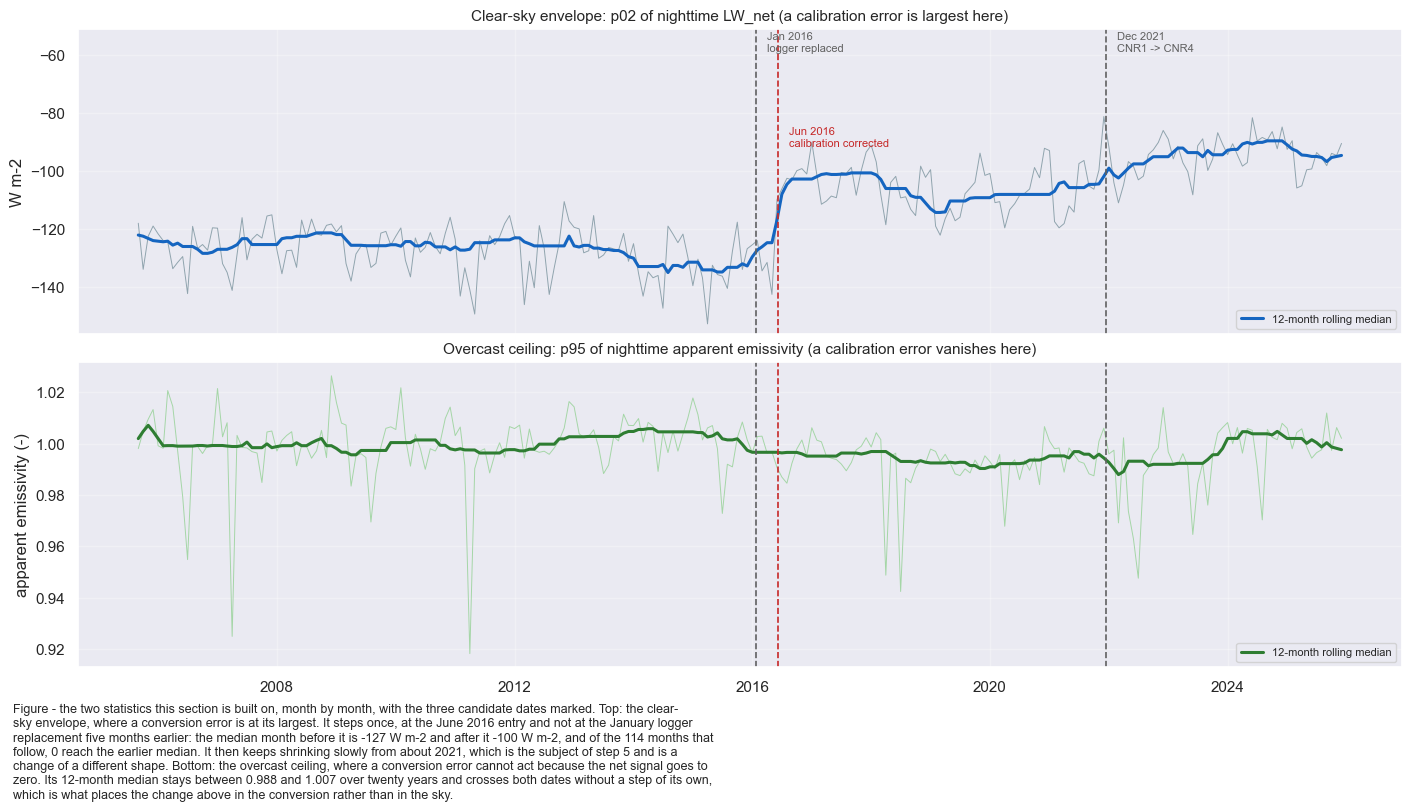

In [28]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 8), dpi=100, layout='constrained', sharex=True)

# The two 2016 dates are five months apart, so their labels are staggered vertically rather than
# printed on top of each other, which is what the first version of this figure did.
_dates = [(pd.Timestamp(LOGGER_CHANGE), 'Jan 2016\nlogger replaced', '#616161', 0.99),
          (pd.Timestamp(CAL_CHANGE), 'Jun 2016\ncalibration corrected', '#C62828', 0.68),
          (pd.Timestamp(CNR4_INSTALLED), 'Dec 2021\nCNR1 -> CNR4', '#616161', 0.99)]

axs[0].plot(ENVELOPE_M.index, ENVELOPE_M.values, color='#90A4AE', lw=0.7)
axs[0].plot(ENVELOPE_M.index, ENVELOPE_M.rolling(12, center=True, min_periods=6).median(),
            color='#1565C0', lw=2.2, label='12-month rolling median')
axs[0].set_ylabel('W m-2')
axs[0].set_title(f'Clear-sky envelope: p{int(100 * CLEAR_Q):02d} of nighttime LW_net '
                 f'(a calibration error is largest here)', fontsize=11)
axs[0].legend(fontsize=8, loc='lower right')

_ceiling_m = monthly_q(EMIS_NIGHT, OVERCAST_Q)
axs[1].plot(_ceiling_m.index, _ceiling_m.values, color='#A5D6A7', lw=0.7)
axs[1].plot(_ceiling_m.index, _ceiling_m.rolling(12, center=True, min_periods=6).median(),
            color='#2E7D32', lw=2.2, label='12-month rolling median')
axs[1].set_ylabel('apparent emissivity (-)')
axs[1].set_title(f'Overcast ceiling: p{int(100 * OVERCAST_Q)} of nighttime apparent emissivity '
                 f'(a calibration error vanishes here)', fontsize=11)
axs[1].legend(fontsize=8, loc='lower right')

for _ax in axs:
    _ax.grid(alpha=0.3)
    for _d, _t, _c, _y in _dates:
        _ax.axvline(_d, color=_c, ls='--', lw=1.2)
_lo, _hi = axs[0].get_ylim()
axs[0].set_ylim(_lo, _hi + 0.34 * (_hi - _lo))
_lo, _hi = axs[0].get_ylim()
for _d, _t, _c, _y in _dates:
    axs[0].text(_d + pd.Timedelta(days=70), _lo + _y * (_hi - _lo), _t, fontsize=8,
                color=_c, va='top')

figcap(fig, f"the two statistics this section is built on, month by month, with the three "
            f"candidate dates marked. Top: the clear-sky envelope, where a conversion error is at "
            f"its largest. It steps once, at the June 2016 entry and not at the January logger "
            f"replacement five months earlier: the median month before it is "
            f"{ENVELOPE_M.loc[:'2016-05'].median():.0f} W m-2 and after it "
            f"{ENVELOPE_M.loc['2016-07':].median():.0f} W m-2, and of the "
            f"{len(ENVELOPE_M.loc['2016-07':])} months that follow, "
            f"{int((ENVELOPE_M.loc['2016-07':] < ENVELOPE_M.loc[:'2016-05'].median()).sum())} "
            f"reach the earlier median. It then keeps shrinking slowly from about 2021, which is "
            f"the subject of step 5 and is a change of a different shape. Bottom: the overcast "
            f"ceiling, where a conversion error cannot act because the net signal goes to zero. "
            f"Its 12-month median stays between "
            f"{_ceiling_m.rolling(12, center=True, min_periods=6).median().min():.3f} and "
            f"{_ceiling_m.rolling(12, center=True, min_periods=6).median().max():.3f} over twenty "
            f"years and crosses both dates without a step of its own, which is what places the "
            f"change above in the conversion rather than in the sky.")

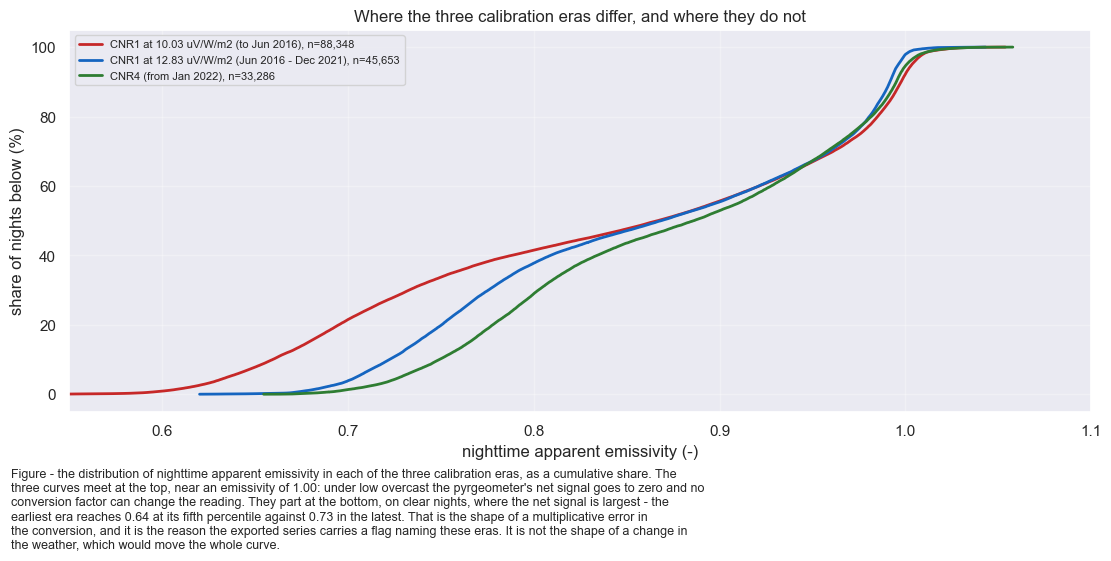

In [29]:
# The same finding as a distribution rather than as a percentile. A multiplicative error on LW_net
# compresses the whole emissivity distribution towards 1 and leaves its upper end where it was.
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=100, layout='constrained')
ERAS = [(f'CNR1 at {SENSITIVITY_OLD} uV/W/m2 (to Jun 2016)', slice(None, '2016-06-06'), '#C62828'),
        (f'CNR1 at {SENSITIVITY_NEW} uV/W/m2 (Jun 2016 - Dec 2021)',
         slice('2016-06-07', '2021-12-14'), '#1565C0'),
        ('CNR4 (from Jan 2022)', slice('2022-01-07', None), '#2E7D32')]
_p05 = {}
for _label, _sl, _colour in ERAS:
    _e = EMIS_NIGHT.loc[_sl].dropna().sort_values()
    _p05[_label] = float(_e.quantile(0.05))
    ax.plot(_e.values, np.linspace(0, 100, len(_e)), color=_colour, lw=2.0,
            label=f'{_label}, n={len(_e):,}')
ax.set_xlabel('nighttime apparent emissivity (-)')
ax.set_ylabel('share of nights below (%)')
ax.set_xlim(0.55, 1.10)
ax.set_title('Where the three calibration eras differ, and where they do not', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
figcap(fig, "the distribution of nighttime apparent emissivity in each of the three calibration "
            "eras, as a cumulative share. The three curves meet at the top, near an emissivity of "
            "1.00: under low overcast the pyrgeometer's net signal goes to zero and no conversion "
            "factor can change the reading. They part at the bottom, on clear nights, where the "
            f"net signal is largest - the earliest era reaches "
            f"{min(_p05.values()):.2f} at its fifth percentile against "
            f"{max(_p05.values()):.2f} in the latest. That is the shape of a multiplicative error "
            "in the conversion, and it is the reason the exported series carries a flag naming "
            "these eras. It is not the shape of a change in the weather, which would move the "
            "whole curve.")

::: {.callout-important title="The exported series is not homogeneous across 7 June 2016"}
Values recorded before that date convert the pyrgeometer's voltage with a factor 28 % too small and
therefore **read low**, by an amount proportional to how clear the sky was: of order 12 W m-2 in the
middle of the distribution and up to some 30 W m-2 on a clear, dry night. Values after it are on the
instrument's own calibration.

This is **not corrected here**, and the reason is specific rather than cautious. Undoing it requires
splitting each stored value back into the instrument's own emission and its net signal, which needs
the radiometer's **body temperature** — a channel this product does not read and, for the era
concerned, one whose treatment in the processing chain that produced these values cannot be verified
from the files available. Rescaling with air temperature as a proxy would import an unverified model
of that chain into the exported numbers.

What is exported instead is a **`SOURCE` flag naming the calibration era**, so that the break is
visible in the file rather than only in this notebook, and the size and shape of the offset are
recorded here and on the documentation page. Whoever holds the raw voltages, or the body-temperature
channel, can do the arithmetic; whoever holds only this product should filter on the flag.
:::

### 4️⃣ The January 2016 acquisition change did nothing

The changeover that moved `TA` by 1.3 °C is not where this variable moves, and two independent
things say so. The logger program installed at the changeover carries the **same** multiplier as
the CR10X programs before it, which step 1 asserts. And the four months that lie between the two
dates — February to May 2016, recorded by the new logger and the old calibration factor — sit
inside the quiet-year range of the same statistic that puts the second half of 2016 far outside it.

The distinction matters because the two dates are five months apart and easy to conflate. A reader
who assumes the January date will place the break in the wrong quarter, and will expect it to
coincide with the `TA` break, which it does not.

### 5️⃣ The December 2021 boundary

Two candidate causes fall on the same date and cannot be separated from each other: the radiometer
was replaced on 14 December 2021, and the `mst` screening ends on 31 December 2021. Unlike `SW_IN`,
where notebook `01` could put both to an external reference, there is nothing here to test against
except the same physics.

The observed level change is real and is the thing a user notices first: the median rises from
about 316 W m-2 over 2019-2021 to about 326 over 2022-2024. The question is how much of that is
weather, and whether whatever is left is a step at the boundary or part of something slower.

In [30]:
# Step one: how much of the level change does temperature alone account for? The sensitivity is
# derived from the record's own emissivity and mean temperature rather than assumed.
PERIOD_BEFORE, PERIOD_AFTER = ('2019', '2021'), ('2022', '2024')
_emis_ref = float(EMIS_NIGHT.loc['2006':'2020'].median())
_tmean = float(TA_DIAG.where(TA_IS_MEASURED).loc['2006':'2021'].mean()) + 273.15
DLW_DTA = 4 * _emis_ref * SIGMA * _tmean ** 3

_lw_a = float(LW_FINAL.loc[PERIOD_BEFORE[0]:PERIOD_BEFORE[1]].median())
_lw_b = float(LW_FINAL.loc[PERIOD_AFTER[0]:PERIOD_AFTER[1]].median())
_ta = TA_DIAG.where(TA_IS_MEASURED)
_ta_a = float(_ta.loc[PERIOD_BEFORE[0]:PERIOD_BEFORE[1]].mean())
_ta_b = float(_ta.loc[PERIOD_AFTER[0]:PERIOD_AFTER[1]].mean())

tabcap("the level change across the December 2021 boundary, and how much of it the temperature "
       "difference between the two periods accounts for through the Stefan-Boltzmann relation. "
       "The residual is what the rest of this step is about")
display(pd.DataFrame({
    'LW_IN median (W m-2)': [round(_lw_a, 2), round(_lw_b, 2), round(_lw_b - _lw_a, 2)],
    'TA mean (degC)': [round(_ta_a, 3), round(_ta_b, 3), round(_ta_b - _ta_a, 3)],
}, index=[f'{PERIOD_BEFORE[0]}-{PERIOD_BEFORE[1]}', f'{PERIOD_AFTER[0]}-{PERIOD_AFTER[1]}',
          'difference']))

_predicted = (_ta_b - _ta_a) * DLW_DTA
_residual = (_lw_b - _lw_a) - _predicted
print(f"dLW/dTA at this site: {DLW_DTA:.2f} W m-2 per K")
print(f"observed change   {_lw_b - _lw_a:+.2f} W m-2")
print(f"temperature alone {_predicted:+.2f} W m-2   ->  residual {_residual:+.2f} W m-2")
print("\nSo temperature accounts for about "
      f"{100 * _predicted / (_lw_b - _lw_a):.0f} % of the level change and not for the rest. "
      "That does not make the rest an instrument effect: a warmer atmosphere is also a moister "
      "one, and both raise the sky's emissivity. The tests below ask the different question of "
      "whether anything happens AT the boundary.")

Table - the level change across the December 2021 boundary, and how much of it the temperature
difference between the two periods accounts for through the Stefan-Boltzmann relation. The residual
is what the rest of this step is about



,LW_IN median (W m-2),TA mean (degC)
2019-2021,316.32,9.849
2022-2024,326.01,10.565
difference,9.69,0.715


dLW/dTA at this site: 4.43 W m-2 per K
observed change   +9.69 W m-2
temperature alone +3.17 W m-2   ->  residual +6.52 W m-2

So temperature accounts for about 33 % of the level change and not for the rest. That does not make the rest an instrument effect: a warmer atmosphere is also a moister one, and both raise the sky's emissivity. The tests below ask the different question of whether anything happens AT the boundary.


In [31]:
# Step two: does anything happen AT the boundary? The same month-matched statistic as at June 2016,
# on the first half of 2022 against the first half of the three preceding years.
SCREENING_YEAR = 2022
_quiet_first = placebo_ratios(ENVELOPE_M, FIRSTHALF, BOUNDARIES)
DEC2021_TEST = matched_ratio(ENVELOPE_M, FIRSTHALF, [2019, 2020, 2021], [SCREENING_YEAR])

tabcap("the December 2021 boundary measured the same way as June 2016, and beside it. The "
       "quiet-year range is the same statistic at every year of the record whose window holds "
       "neither boundary, and is what each test value is read against")
_cmp = pd.DataFrame({
    f'Jan-Jun {SCREENING_YEAR} against {SCREENING_YEAR - 3}-{SCREENING_YEAR - 1}': DEC2021_TEST,
    'Jul-Dec 2016 against 2013-2015': JUN2016_TEST,
}).T
_cmp['quiet-year range'] = [f'{_quiet_first.min():.3f} - {_quiet_first.max():.3f}',
                            f'{_quiet_autumn.min():.3f} - {_quiet_autumn.max():.3f}']
display(_cmp)

print(f"The December 2021 boundary does move this statistic, and by more than a quiet year does. "
      f"It moves it by about half as much as the calibration change did: "
      f"{100 * (1 - DEC2021_TEST['ratio']):.0f} % against "
      f"{100 * (1 - JUN2016_TEST['ratio']):.0f} %.")

assert DEC2021_TEST['ratio'] > JUN2016_TEST['ratio'], (
    "the December 2021 boundary now moves the clear-sky envelope by more than the June 2016 "
    "calibration change did, which would make it the larger of the two events and would need a "
    "different treatment than the one this notebook gives it")

Table - the December 2021 boundary measured the same way as June 2016, and beside it. The quiet-year
range is the same statistic at every year of the record whose window holds neither boundary, and is
what each test value is read against



,months compared,before (W m-2),after (W m-2),ratio,quiet-year range
Jan-Jun 2022 against 2019-2021,18 vs 6,-113.9,-101.3,0.8893,0.956 - 1.077
Jul-Dec 2016 against 2013-2015,18 vs 6,-127.2,-101.9,0.8006,0.979 - 1.042


The December 2021 boundary does move this statistic, and by more than a quiet year does. It moves it by about half as much as the calibration change did: 11 % against 20 %.


In [32]:
# Step three: can the change be identified? At June 2016 it can, because a conversion factor scales
# every percentile of the tail by one number and the data do exactly that. Here the same test is
# run, together with the physically pinned ceiling, which a conversion error cannot move.
_QS = (0.01, 0.02, 0.05, 0.10, 0.20)


def era_ratios(before, after):
    return pd.Series({f'p{int(100 * _q):02d}': float(
        yearly_q(LWNET_NIGHT, _q).loc[after[0]:after[1]].mean()
        / yearly_q(LWNET_NIGHT, _q).loc[before[0]:before[1]].mean()) for _q in _QS})


_shape = pd.DataFrame({
    'across June 2016 (2017-2021 / 2006-2015)': era_ratios((2006, 2015), (2017, 2021)),
    'across Dec 2021 (2022-2025 / 2017-2021)': era_ratios((2017, 2021), (2022, 2025)),
    'a quiet interval (2012-2015 / 2007-2011)': era_ratios((2007, 2011), (2012, 2015)),
}).T
_shape['spread across percentiles'] = (_shape[[f'p{int(100 * _q):02d}' for _q in _QS]]
                                       .max(axis=1) - _shape[[f'p{int(100 * _q):02d}' for _q in _QS]]
                                       .min(axis=1)).round(4)
_shape['clear-sky change (%)'] = (100 * (_shape[[f'p{int(100 * _q):02d}' for _q in _QS]]
                                         .mean(axis=1) - 1)).round(2)
_shape['overcast ceiling change (%)'] = [round(step_at(CEILING_Y, 2016), 2),
                                         round(step_at(CEILING_Y, SCREENING_YEAR), 2),
                                         round(step_at(CEILING_Y, 2013), 2)]
tabcap("the shape of each change rather than its size. Two things are being read here. First, "
       "whether the change is confined to the clear-sky end, which the last two columns compare: "
       "both real changes move the clear-sky envelope by ten to twenty times what they move the "
       "physically pinned overcast ceiling. Second, whether one factor describes the whole "
       "clear-sky tail, which the spread column reports: at June 2016 it does, at December 2021 "
       "it does no better than a quiet interval does")
display(_shape.round(4))

_spread_2016 = float(_shape.loc['across June 2016 (2017-2021 / 2006-2015)', 'spread across percentiles'])
_spread_2021 = float(_shape.loc['across Dec 2021 (2022-2025 / 2017-2021)', 'spread across percentiles'])
print(f"spread across percentiles: June 2016 {_spread_2016:.4f}, December 2021 {_spread_2021:.4f}")
for _row in _shape.index[:2]:
    _clear, _ceil = abs(_shape.loc[_row, 'clear-sky change (%)']), abs(_shape.loc[_row, 'overcast ceiling change (%)'])
    print(f"  {_row}: clear-sky {_clear:.1f} % against overcast ceiling {_ceil:.2f} %, "
          f"a factor of {_clear / _ceil:.0f}")
    assert _clear > 5 * _ceil, (
        f"{_row}: the change is no longer concentrated at the clear-sky end of the distribution, "
        f"which is where a conversion error acts and nowhere else")

assert _spread_2016 < _spread_2021, (
    "the December 2021 change is now as cleanly multiplicative as the June 2016 one, which would "
    "make it identifiable as a conversion change and would change what this section concludes")
assert abs(step_at(CEILING_Y, SCREENING_YEAR)) < 1.0, (
    "the overcast ceiling now moves at the December 2021 boundary by as much as an ordinary "
    "change in the clear-sky end. It is pinned by physics, so a change in it would be a change in "
    "the measurement under overcast, which no conversion factor can produce")
print("\nBoth changes sit at the clear-sky end and barely touch the overcast ceiling, which is "
      "what keeps both of them inside the part of the signal a conversion error can reach. Only "
      "one of them is described by a single factor.")

Table - the shape of each change rather than its size. Two things are being read here. First,
whether the change is confined to the clear-sky end, which the last two columns compare: both real
changes move the clear-sky envelope by ten to twenty times what they move the physically pinned
overcast ceiling. Second, whether one factor describes the whole clear-sky tail, which the spread
column reports: at June 2016 it does, at December 2021 it does no better than a quiet interval does



,p01,p02,p05,p10,p20,spread across percentiles,clear-sky change (%),overcast ceiling change (%)
across June 2016 (2017-2021 / 2006-2015),0.8272,0.8304,0.8282,0.8232,0.8204,0.0100,-17.41,-1.02
across Dec 2021 (2022-2025 / 2017-2021),0.8988,0.8953,0.8979,0.9082,0.9319,0.0366,-9.36,0.46
a quiet interval (2012-2015 / 2007-2011),1.0353,1.0292,1.0214,1.0191,1.0003,0.0350,2.11,0.13


spread across percentiles: June 2016 0.0100, December 2021 0.0366
  across June 2016 (2017-2021 / 2006-2015): clear-sky 17.4 % against overcast ceiling 1.02 %, a factor of 17
  across Dec 2021 (2022-2025 / 2017-2021): clear-sky 9.4 % against overcast ceiling 0.46 %, a factor of 20

Both changes sit at the clear-sky end and barely touch the overcast ceiling, which is what keeps both of them inside the part of the signal a conversion error can reach. Only one of them is described by a single factor.


::: {.callout-important title="December 2021: a change this notebook cannot attribute"}
The record does move across the boundary, and the size of it accounts for most of the residual left
after temperature. What is missing is any way to say **why**, and there are three candidates that
these data cannot separate:

- **the instrument.** The CNR4 replaced the CNR1 on 14 December 2021 and its longwave channel
  carries its own calibration factor, 10.85 µV/W/m² against the 12.83 its predecessor had been given
  in June 2016. The absolute scale of the conversion therefore did change.
- **the screening.** The `mst` screening ends on 31 December 2021 and `diive` begins on 1 January
  2022, and the two do not overlap, so nothing can be compared between them.
- **the atmosphere.** The clear-sky end of this record has been moving in the same direction since
  about 2017, which is what a warmer and moister lower atmosphere does to downwelling longwave, and
  the change at the boundary is of the size that trend would produce in a few years.

At June 2016 the shape of the change identified it: a conversion factor scales the whole clear-sky
tail by one number, the data did that, and the fieldbook named the number. Here the shape does not
identify anything — the ratio across the tail is no steadier than in a quiet interval — and the
fieldbook records a replacement but no reprocessing of the earlier record.

The sibling channel bounds this from one side only. `SW_IN` comes off the same radiometer and
notebook `01` shows it does not step across December 2021, against two independent references. That
rules out a common-mode fault in the wiring, the logger or the acquisition; it says nothing about
the pyrgeometer, which is a different detector with its own calibration.

**Nothing is corrected**, because correcting an unattributed change would replace a measurement with
a guess — the same conclusion `01` and `03` reach for the drifts they find. What is exported is the
`SOURCE` flag, which puts the two instruments in different codes so that a reader who needs one era
alone can have it.
:::

#### What this section settles

`LW_IN_T1_47_1` is one instrument until December 2021 — a Kipp & Zonen CNR1, serial 020484 — and
another after it, and it is **not homogeneous across 7 June 2016**, when the pyrgeometer's
calibration factor was corrected from the pyranometer's value to its own. That break is in the
middle of the record, it is larger than anything at either hardware date, and it is the one thing a
user of this product most needs to know.

It is **homogeneous across the January 2016 acquisition change**, which replaced the logger and
neither the instrument nor its conversion. Across the **December 2021** boundary the record moves
by about half as much as at June 2016, and nothing available here identifies a cause.

No correction is applied for any of the three, for two different reasons: at June 2016 because
undoing the change needs a channel this product does not have, and at December 2021 because nothing
says what to undo. What is exported instead is the measured series plus a flag naming the era each
value belongs to, and the assertions above exist so that this stops being a matter of memory: if a
re-run ever fails to find the June 2016 step, or finds one in the four months between the two 2016
dates, or finds December 2021 to be the larger of the two events, it fails here rather than
exporting a product that quietly reports a calibration change as weather.

***

## 🏷️ Provenance flag: which instrument and which calibration

One column name spans two instruments and three calibration factors, so the exported file says
which of them produced each value. The flag is built from dates the section above established: two
from the fieldbook, one from the logger program that the fieldbook says was uploaded.

The changeover interval gets **its own code** rather than being assigned to one side. The CNR4 was
installed on 14 December 2021 but its own constants only reached the logger program on 7 January
2022, so for three weeks the new instrument was read through the old instrument's factor. The
fieldbook cannot narrow that, and neither can the data over so short a winter window, so the
interval is marked as undetermined — the same treatment notebook `08` gives its 71-day 2018
transition.

In [33]:
FLAGCOL = f'FLAG_{TARGET}_SOURCE'
# Written with inclusive end dates, so the legend reads the way a data user would filter.
_last_cnr1 = (pd.Timestamp(CNR4_INSTALLED) - pd.Timedelta(days=1)).date()
_last_undet = (pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(days=1)).date()
_last_old_cal = (pd.Timestamp(CAL_CHANGE) - pd.Timedelta(days=1)).date()
SOURCE_LEGEND = {
    0: f'0 = CNR4 on its own calibration factor (from {CNR4_CONSTANTS})',
    1: f"1 = CNR1 at {SENSITIVITY_NEW} uV/W/m2, the pyrgeometer's own factor ({CAL_CHANGE} to "
       f'{_last_cnr1})',
    2: f'2 = CNR1 at {SENSITIVITY_OLD} uV/W/m2, the PYRANOMETER factor - reads low (to '
       f'{_last_old_cal})',
    3: f'3 = changeover, era undetermined ({CNR4_INSTALLED} to {_last_undet}): CNR4 installed, '
       f'CNR1 constants still in the program',
}

source = pd.Series(0, index=full_index, dtype='int8', name=FLAGCOL)
source.loc[:pd.Timestamp(CAL_CHANGE) - pd.Timedelta(minutes=15)] = 2
source.loc[pd.Timestamp(CAL_CHANGE):pd.Timestamp(CNR4_INSTALLED) - pd.Timedelta(minutes=15)] = 1
source.loc[pd.Timestamp(CNR4_INSTALLED):pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(minutes=15)] = 3
# code 0 is what remains, from CNR4_CONSTANTS onwards

tabcap("the exported provenance flag, by code. Code 2 is the era that reads low, and it is more "
       "than half the record; code 3 is the three weeks the evidence cannot assign to either "
       "instrument")
_flagtab = pd.DataFrame({
    'meaning': {c: SOURCE_LEGEND[c] for c in sorted(SOURCE_LEGEND)},
    'records': source.value_counts().reindex(sorted(SOURCE_LEGEND)).astype(int),
    'measured records': source.where(lw_2005_2025[TARGET].notna()).value_counts()
                              .reindex(sorted(SOURCE_LEGEND)).fillna(0).astype(int),
})
_flagtab['share of measured (%)'] = (100 * _flagtab['measured records']
                                     / _flagtab['measured records'].sum()).round(2)
_flagtab.index.name = 'code'
with pd.option_context('display.max_colwidth', 130):
    display(_flagtab)

# The flag is defined everywhere, describes the whole index once, and its boundaries are the dates
# the section above derived rather than dates typed here twice.
assert source.notna().all(), "the source flag is not defined everywhere"
assert set(source.unique()) == set(SOURCE_LEGEND), \
    "a code appears in the flag that the legend does not describe, or the other way round"
assert source.loc[:'2016-06-06 23:45'].eq(2).all() and source.loc['2016-06-07 00:15':'2021-12-14 23:45'].eq(1).all(), \
    "the two CNR1 eras no longer meet exactly at the calibration change"
assert int(source.eq(3).sum()) == len(pd.date_range(f'{CNR4_INSTALLED} 00:15',
                                                    pd.Timestamp(CNR4_CONSTANTS) - pd.Timedelta(minutes=15),
                                                    freq='30min')), \
    "the undetermined interval is not the interval between the two December/January dates"

Table - the exported provenance flag, by code. Code 2 is the era that reads low, and it is more than
half the record; code 3 is the three weeks the evidence cannot assign to either instrument



,meaning,records,measured records,share of measured (%)
code,,,,
0,0 = CNR4 on its own calibration factor (from 2022-01-07),69840,69724,19.87
1,"1 = CNR1 at 12.83 uV/W/m2, the pyrgeometer's own factor (2016-06-07 to 2021-12-14)",96816,96037,27.36
2,"2 = CNR1 at 10.03 uV/W/m2, the PYRANOMETER factor - reads low (to 2016-06-06)",188112,184104,52.46
3,"3 = changeover, era undetermined (2021-12-15 to 2022-01-06): CNR4 installed, CNR1 constants still in the program",1104,1104,0.31


***

## 🚫 No gap-filling here

As in notebook `05`, the series is exported as measured.

Consequences for anything consuming this file:

- `LW_IN_T1_47_1` **contains `NaN`**. Code that assumes a complete series will break or silently
  propagate `NaN`.
- There is **no `FLAG_..._ISFILLED` column**, because there is nothing to flag. Non-null means
  measured.
- If a complete series is needed later, fill it downstream where the fill can be flagged in that
  product's own terms. `LW_IN` is a comparatively easy fill — it is smooth and strongly tied to air
  temperature and cloudiness — but that is a downstream decision, not this notebook's, and a fill
  would have to respect the calibration eras the flag names rather than train one model across them.

***

## ➡️ Prepare dataframe for export

In [34]:
VALCOL = TARGET

export_df = lw_2005_2025[[VALCOL]].copy()
export_df[FLAGCOL] = source
tabcap("the exported frame: the measured series and the flag naming the instrument and calibration "
       "factor behind each value")
display(export_df)

Table - the exported frame: the measured series and the flag naming the instrument and calibration
factor behind each value



,LW_IN_T1_47_1,FLAG_LW_IN_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,
2005-09-14 00:15:00,NaN,2
2005-09-14 00:45:00,NaN,2
2005-09-14 01:15:00,NaN,2
2005-09-14 01:45:00,NaN,2
2005-09-14 02:15:00,NaN,2
...,...,...
2025-12-31 21:45:00,210.420480,0
2025-12-31 22:15:00,210.648200,0
2025-12-31 22:45:00,211.147057,0


Sanity check. The series is **not** expected to be complete, so the check is that the index is
sound, every present value is physically plausible longwave, the flag is defined at every record,
and the gaps are the ones this notebook knows about.

In [35]:
_lo, _hi = LW_IN_PLAUSIBLE_WM2

print(f"Records:          {len(export_df):,}")
print(f"Measured:         {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:        {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} W m-2")

assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df[VALCOL].min() >= _lo and export_df[VALCOL].max() <= _hi, \
    f"values outside {_lo}-{_hi} W m-2"
assert export_df[VALCOL].notna().any(), "no data at all"
assert export_df[FLAGCOL].notna().all(), "the provenance flag is not defined at every record"
print("\nAll checks passed.")

tabcap("summary statistics of the exported value column")
display(export_df[[VALCOL]].describe())

Records:          355,872
Measured:         350,969 (98.62%)
Missing (NaN):    4,903 (1.38%)
Duplicate index:  0
Index gaps:       0
Index:            2005-09-14 00:15:00 -> 2025-12-31 23:45:00
Min / max:        135.45 / 441.78 W m-2

All checks passed.
Table - summary statistics of the exported value column



,LW_IN_T1_47_1
count,350969.000000
mean,310.568035
std,45.568588
min,135.445129
25%,282.447887
50%,315.847198
75%,343.420273
max,441.779694


### Per-year statistics

`coverage_%` shows where the real gaps are: 2012 is the year of the removed fault periods, and
2009, 2016 and 2019 have sensor outages that are left as gaps. 2005 is a partial year by
construction, since the record starts on 14 September, which is also why its median is the lowest in
the table — it covers only autumn.

The `calibration` column marks the eras the flag names. The level rises across both boundaries;
what the section above establishes is that the first rise is a correction of the conversion and the
second cannot be attributed.

In [36]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['possible'] = export_df[VALCOL].groupby(export_df.index.year).size()
_yr['coverage_%'] = (100 * _yr['count'] / _yr['possible']).round(2)
_yr['calibration'] = (export_df[FLAGCOL].groupby(export_df.index.year)
                      .agg(lambda s: '/'.join(str(int(v)) for v in sorted(s.unique()))))
tabcap("the exported series year by year. The `calibration` column gives the flag codes present in "
       "that year, so the two years holding a boundary are the two carrying more than one code")
display(_yr.round(2))

_med = _yr['median']
assert ((_med > _lo) & (_med < _hi)).all(), "a yearly median is outside the plausible band"
print(f"All yearly medians between {_med.min():.2f} and {_med.max():.2f} W m-2.")
print(f"Full-year medians (2006-2025) span {_med.loc[2006:].min():.2f} to "
      f"{_med.loc[2006:].max():.2f} W m-2, sd {_med.loc[2006:].std():.2f}.")

Table - the exported series year by year. The `calibration` column gives the flag codes present in
that year, so the two years holding a boundary are the two carrying more than one code



,count,median,min,max,std,possible,coverage_%,calibration
TIMESTAMP_MIDDLE,,,,,,,,
2005,5184,296.53,166.98,387.15,44.45,5232,99.08,2
2006,17396,311.56,160.44,415.70,50.49,17520,99.29,2
2007,17422,310.10,164.10,411.22,46.83,17520,99.44,2
2008,17423,312.23,164.83,410.42,49.23,17568,99.17,2
2009,16917,307.12,149.90,414.92,46.90,17520,96.56,2
2010,17291,307.81,149.98,420.89,47.11,17520,98.69,2
2011,17472,308.11,170.92,411.45,47.08,17520,99.73,2
2012,16210,314.01,135.45,419.37,50.73,17568,92.27,2
2013,17362,311.62,169.86,441.78,45.75,17520,99.10,2


All yearly medians between 296.53 and 329.94 W m-2.
Full-year medians (2006-2025) span 307.12 to 329.94 W m-2, sd 6.43.


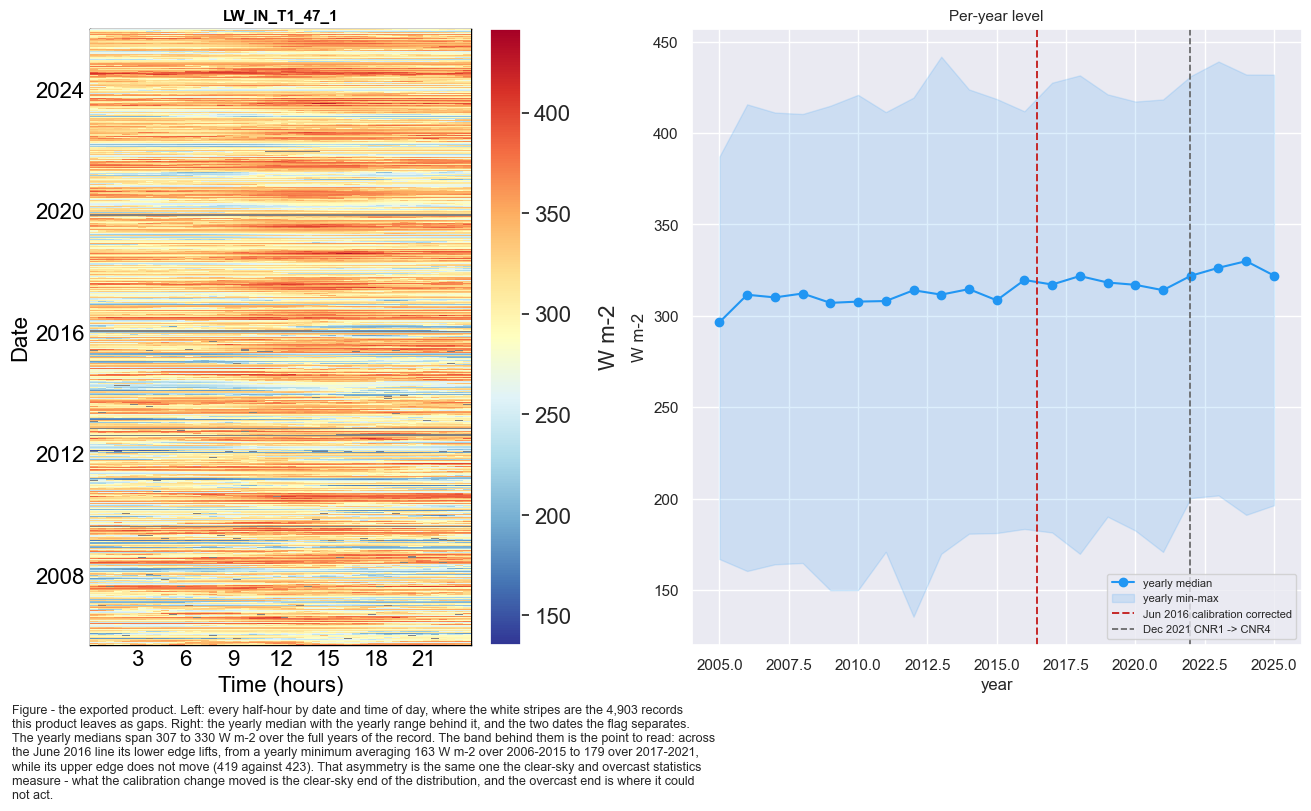

In [37]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

_yr['median'].plot(ax=axs[1], marker='o', color='#2196F3', label='yearly median')
axs[1].fill_between(_yr.index, _yr['min'], _yr['max'], color='#2196F3', alpha=.15,
                    label='yearly min-max')
axs[1].axvline(2016.44, color='#C62828', ls='--', lw=1.4, label='Jun 2016 calibration corrected')
axs[1].axvline(2021.96, color='#616161', ls='--', lw=1.2, label='Dec 2021 CNR1 -> CNR4')
axs[1].set_ylabel('W m-2')
axs[1].set_xlabel('year')
axs[1].set_title('Per-year level', fontsize=11)
axs[1].legend(fontsize=8)

_min_before = float(_yr.loc[2006:2015, 'min'].mean())
_min_after = float(_yr.loc[2017:2021, 'min'].mean())
_max_before = float(_yr.loc[2006:2015, 'max'].mean())
_max_after = float(_yr.loc[2017:2021, 'max'].mean())
figcap(fig, f"the exported product. Left: every half-hour by date and time of day, where the white "
            f"stripes are the {int(export_df[VALCOL].isna().sum()):,} records this product leaves "
            f"as gaps. Right: the yearly median with the yearly range behind it, and the two dates "
            f"the flag separates. The yearly medians span "
            f"{_med.loc[2006:].min():.0f} to {_med.loc[2006:].max():.0f} W m-2 over the full years "
            f"of the record. The band behind them is the point to read: across the June 2016 line "
            f"its lower edge lifts, from a yearly minimum averaging {_min_before:.0f} W m-2 over "
            f"2006-2015 to {_min_after:.0f} over 2017-2021, while its upper edge does not move "
            f"({_max_before:.0f} against {_max_after:.0f}). That asymmetry is the same one the "
            f"clear-sky and overcast statistics measure - what the calibration change moved is the "
            f"clear-sky end of the distribution, and the overcast end is where it could not act.")

***

## 💾 Save to file

In [38]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\06_METEO_LW_IN_2005-2025.parquet (0.038 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\06_METEO_LW_IN_2005-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [39]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"median:    {float(_written[VALCOL].median()):.2f} W m-2")
print(f"min / max: {float(_written[VALCOL].min()):.2f} / {float(_written[VALCOL].max()):.2f} W m-2")

assert list(_written.columns) == [VALCOL, FLAGCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].notna().sum() == export_df[VALCOL].notna().sum(), \
    "measured count changed on write"
assert _written[FLAGCOL].equals(export_df[FLAGCOL]), "the provenance flag changed on write"
assert _lo < float(_written[VALCOL].median()) < _hi, "median outside plausible range"
print("\nWritten file verified.")

tabcap("the written file read back, by year and by calibration era")
_check = _written.groupby([_written.index.year, _written[FLAGCOL]])[VALCOL].median().unstack()
_check.index.name = 'YEAR'
_check.columns = [f'code {int(c)}' for c in _check.columns]
display(_check.round(2))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\06_METEO_LW_IN_2005-2025.parquet (0.008 seconds).

columns:   ['LW_IN_T1_47_1', 'FLAG_LW_IN_T1_47_1_SOURCE']
index:     2005-09-14 00:15:00 -> 2025-12-31 23:45:00  (355,872 records)
measured:  350,969 (98.62%)
median:    315.85 W m-2
min / max: 135.45 / 441.78 W m-2

Written file verified.
Table - the written file read back, by year and by calibration era



,code 0,code 1,code 2,code 3
YEAR,,,,
2005,NaN,NaN,296.53,NaN
2006,NaN,NaN,311.56,NaN
2007,NaN,NaN,310.10,NaN
2008,NaN,NaN,312.23,NaN
2009,NaN,NaN,307.12,NaN
2010,NaN,NaN,307.81,NaN
2011,NaN,NaN,308.11,NaN
2012,NaN,NaN,314.01,NaN
2013,NaN,NaN,311.62,NaN


***

## End of notebook.

In [40]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-29 01:29:19
Finished: 2026-07-29 01:29:34
Runtime:  00:00:15 (hh:mm:ss)
